# Phân Tích Rủi Ro Tín Dụng – Nova Bank

**Báo cáo nghiên cứu:**Ứng dụng học máy và phân tích danh mục tín dụng trong quản lý rủi ro cho vay tiêu dùng

**Tác giả:**PhamNgocTheKieu

---

> *Notebook này được xây dựng theo khung phân tích của một Credit Risk Analytics, bao gồm: EDA, mô hình dự đoán, giám sát danh mục (DPD, vintage, PSI/CSI), thiết kế thực nghiệm A/B, và pipeline SQL/Python.*

---


# CHƯƠNG 1: GIỚI THIỆU

---


## 1.1. Sự Cần Thiết của Chủ Đề Nghiên Cứu

Rủi ro tín dụng là một trong những thách thức cốt lõi mà các tổ chức tài chính và Fintech phải đối mặt, đặc biệt trong bối cảnh tăng trưởng nhanh của các sản phẩm cho vay tiêu dùng, BNPL (Buy Now Pay Later) và tín dụng kỹ thuật số. Khi một khoản vay không được hoàn trả đúng hạn, tổ chức không chỉ chịu tổn thất về vốn gốc và lãi suất mà còn phải trích lập dự phòng, ảnh hưởng trực tiếp đến lợi nhuận và tỷ lệ an toàn vốn.

Tại Nova Bank, tỷ lệ nợ quá hạn lên đến khoảng **21,8%**– cao hơn gấp 3 đến 7 lần so với chuẩn ngành cho vay tiêu dùng thông thường (3–8%). Điều này đặt ra yêu cầu cấp thiết về việc xây dựng:
- Hệ thống **giám sát danh mục**(DPD, delinquency, vintage curves) để phát hiện sớm tín hiệu rủi ro.
- Mô hình **dự đoán nợ quá hạn**chính xác để hỗ trợ quyết định phê duyệt.
- Framework **thực nghiệm A/B**để kiểm tra chính sách tín dụng trước khi triển khai đại trà.
- **Phân khúc người vay**theo rủi ro để áp dụng chiến lược quản lý phù hợp.

---


## 1.2. Xác Định Mục Tiêu Nghiên Cứu

Nghiên cứu này hướng đến **bốn mục tiêu**phù hợp với quy trình quản lý rủi ro tín dụng trong Fintech:

**Mục tiêu 1 – Phân tích và mô tả dữ liệu (EDA):**Khám phá phân phối, cấu trúc và mối quan hệ giữa các biến; xác định các nhân tố nhân khẩu học, tài chính và lịch sử tín dụng ảnh hưởng đến xác suất nợ quá hạn.

**Mục tiêu 2 – Xây dựng và đánh giá mô hình dự đoán:**Huấn luyện và so sánh ba mô hình (Logistic Regression, Random Forest, Gradient Boosting); giám sát độ lệch phân phối sau triển khai (PSI/CSI).

**Mục tiêu 3 – Giám sát danh mục và Vintage Analysis:**Xây dựng các chỉ số giám sát danh mục (DPD distribution, delinquency rate, roll rate matrix, vintage curves) – các công cụ cốt lõi trong Credit Risk Monitoring.

**Mục tiêu 4 – Thiết kế thực nghiệm và đề xuất khuyến nghị:**Thiết kế framework A/B test (champion-challenger) để kiểm tra chính sách tín dụng; đề xuất chiến lược quản lý danh mục cho vay theo phân khúc rủi ro.

---


## 1.3. Dữ Liệu và Phương Pháp Nghiên Cứu

### 1.3.1. Dữ liệu

Tập dữ liệu gồm **32.581 hồ sơ vay cá nhân**tại ba quốc gia: Mỹ, Anh và Canada, với **29 biến**.

| Nhóm biến | Các biến chính |
|-----------|---------------|
| Nhân khẩu học | `person_age`, `gender`, `marital_status`, `education_level`, `country` |
| Tài chính | `person_income`, `loan_amnt`, `loan_int_rate`, `loan_percent_income`, `debt_to_income_ratio` |
| Lịch sử tín dụng | `cb_person_cred_hist_length`, `cb_person_default_on_file`, `past_delinquencies` |
| Đặc điểm khoản vay | `loan_grade`, `loan_intent`, `person_home_ownership`, `employment_type` |

**Biến mục tiêu**(`loan_status`): `1` = Nợ quá hạn (Default), `0` = Trả đúng hạn.

### 1.3.2. Phương pháp nghiên cứu

Nghiên cứu theo quy trình **5 giai đoạn**phản ánh workflow thực tế của một Credit Risk Analyst:

1. **Tiền xử lý dữ liệu**– Missing values, outlier detection, feature engineering.
2. **EDA & Kiểm định thống kê**– Univariate/Multivariate analysis, Chi-square, Mann-Whitney U.
3. **Xây dựng mô hình**– Stratified split, SMOTE, cross-validation, threshold tuning.
4. **Giám sát danh mục**– DPD distribution, roll rate matrix, vintage curves, PSI/CSI monitoring.
5. **Thực nghiệm & Khuyến nghị**– A/B test framework, risk segmentation, policy recommendations.

---


# CHƯƠNG 2: KẾT QUẢ NGHIÊN CỨU VÀ THẢO LUẬN

---

## 2.1. Tiền Xử Lý Dữ Liệu và Mô Tả Dữ Liệu

---

### 2.1.1. Import Thư Viện và Cấu Hình


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2_contingency, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# ── Cấu hình style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})
sns.set_palette("Set2")

# ── Bảng màu chủ đề ────────────────────────────────────────────────────────
C_SAFE   = '#2ECC71'   # Xanh lá – an toàn
C_RISK   = '#E74C3C'   # Đỏ – rủi ro
C_BLUE   = '#3498DB'
C_ORANGE = '#E67E22'
C_PURPLE = '#9B59B6'
C_TEAL   = '#1ABC9C'
PALETTE2 = [C_SAFE, C_RISK]

print(" Cấu hình hoàn tất.")


 Cấu hình hoàn tất.


### 2.1.2. Tải Dữ Liệu và Khám Phá Ban Đầu


In [ ]:
# ── Đọc dữ liệu ───────────────────────────────────────────────────────────
FILE = 'Credit_Risk_Dataset.xlsx'
df   = pd.read_excel(FILE)

print(f" Kích thước dữ liệu: {df.shape[0]:,} hàng × {df.shape[1]} cột")
print()
df.head()


 Kích thước dữ liệu: 32,581 hàng × 29 cột



,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


In [ ]:
# ── Thông tin tổng quan ────────────────────────────────────────────────────
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

In [ ]:
# ── Thống kê mô tả ────────────────────────────────────────────────────────
df.describe(include='all').T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
client_ID,32581,32581,CUST_32581,1,nan,nan,nan,nan,nan,nan,nan
person_age,32581.000000,nan,nan,nan,27.734600,6.348078,20.000000,23.000000,26.000000,30.000000,144.000000
person_income,32581.000000,nan,nan,nan,66074.848470,61983.119168,4000.000000,38500.000000,55000.000000,79200.000000,6000000.000000
person_home_ownership,32581,4,RENT,16446,nan,nan,nan,nan,nan,nan,nan
person_emp_length,31686.000000,nan,nan,nan,4.789686,4.142630,0.000000,2.000000,4.000000,7.000000,123.000000
loan_intent,32581,6,EDUCATION,6453,nan,nan,nan,nan,nan,nan,nan
loan_grade,32581,7,A,10777,nan,nan,nan,nan,nan,nan,nan
loan_amnt,32581.000000,nan,nan,nan,9589.371106,6322.086646,500.000000,5000.000000,8000.000000,12200.000000,35000.000000
loan_int_rate,29465.000000,nan,nan,nan,11.011695,3.240459,5.420000,7.900000,10.990000,13.470000,23.220000
loan_status,32581.000000,nan,nan,nan,0.218164,0.413006,0.000000,0.000000,0.000000,0.000000,1.000000


In [ ]:
# ── Kiểm tra giá trị thiếu ────────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0]
pct     = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Số lượng thiếu': missing, '% thiếu': pct})

print("=== GIÁ TRỊ THIẾU ===")
display(miss_df.style.bar(subset=['% thiếu'], color=C_RISK))


=== GIÁ TRỊ THIẾU ===


,Số lượng thiếu,% thiếu
person_emp_length,895,2.750000
loan_int_rate,3116,9.560000


**Nhận xét tổng quan dữ liệu:**
Tập dữ liệu gồm 32.581 hồ sơ vay với 29 biến. Biến mục tiêu `loan_status` là bài toán **phân loại nhị phân không cân bằng**(~78% trả đúng hạn vs ~22% nợ quá hạn).

Các điểm cần lưu ý trước phân tích:
- `loan_int_rate` và `person_emp_length` có giá trị thiếu → cần impute thận trọng.
- `person_age`, `person_income`, `person_emp_length` có thể chứa outlier cực trội.
- `loan_grade` (A–G) là biến xếp hạng tín dụng quan trọng, rủi ro tăng dần từ A đến G.
- Cần mô phỏng thêm cột `dpd` (days past due) để thực hiện portfolio monitoring trong các phần sau.

---


### 2.1.3. Làm Sạch và Tiền Xử Lý Dữ Liệu

#### a) Xử lý giá trị thiếu và tạo biến mới


In [ ]:
# ── Điền giá trị thiếu ────────────────────────────────────────────────────
# loan_int_rate: điền theo trung vị của từng nhóm xếp hạng (giữ quan hệ grade ~ rate)
df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df.groupby('loan_grade')['loan_int_rate'].transform('median'))

# person_emp_length: điền trung vị toàn tập
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# ── Biến nhóm ──────────────────────────────────────────────────────────────
bins_age   = [17, 25, 35, 45, 55, 100]
labels_age = ['18-25','26-35','36-45','46-55','56+']
df['age_group'] = pd.cut(df['person_age'], bins=bins_age, labels=labels_age)

bins_inc   = [0, 30000, 60000, 90000, 120000, df['person_income'].max()+1]
labels_inc = ['<30K','30-60K','60-90K','90-120K','>120K']
df['income_group'] = pd.cut(df['person_income'], bins=bins_inc, labels=labels_inc)

df['default_label'] = df['loan_status'].map({0:'Trả đúng hạn', 1:'Nợ quá hạn'})

# ── Mô phỏng cột DPD (Days Past Due) ──────────────────────────────────────
# Trong thực tế, DPD được lấy từ hệ thống core banking.
# Ở đây ta mô phỏng dựa trên loan_status và các chỉ số rủi ro để phục vụ
# portfolio monitoring (Mục 2.4).
np.random.seed(42)
dpd_vals = np.where(
    df['loan_status'] == 0,
    np.random.choice([0, 1, 5, 10], size=len(df), p=[0.85, 0.08, 0.05, 0.02]),
    np.random.choice([30, 60, 90, 120, 180], size=len(df), p=[0.25, 0.25, 0.25, 0.15, 0.10])
)
df['dpd'] = dpd_vals

# ── Mô phỏng cột vintage_month (tháng giải ngân) ──────────────────────────
months = pd.date_range('2022-01', periods=24, freq='MS').tolist()  # FIX: convert to list
df['vintage_month'] = np.random.choice(months, size=len(df))
df['vintage_month'] = pd.to_datetime(df['vintage_month'])

print("Lam sach du lieu hoan tat.")
print(f"   Kich thuoc sau khi lam sach: {df.shape}")
print(f"   Cot DPD: min={df['dpd'].min()}, max={df['dpd'].max()}, mean={df['dpd'].mean():.1f}")


Lam sach du lieu hoan tat.
   Kich thuoc sau khi lam sach: (32581, 34)
   Cot DPD: min=0, max=180, mean=18.0


**Nhận xét về xử lý giá trị thiếu:**
- `loan_int_rate` được điền theo trung vị của từng nhóm `loan_grade` thay vì trung vị toàn bộ, đảm bảo tính nhất quán giữa xếp hạng rủi ro và lãi suất.
- `person_emp_length` được điền bằng trung vị toàn tập — phù hợp cho biến liên tục không có nhóm rõ ràng.
- Cột `dpd` (Days Past Due) và `vintage_month` được mô phỏng để phục vụ **portfolio monitoring**trong Mục 2.4. Trong môi trường thực tế (MoMo, ngân hàng), các cột này được lấy trực tiếp từ hệ thống core banking qua SQL pipeline.

---


#### b) Phát hiện và xử lý Outlier


In [ ]:
# ── Phát hiện outlier bằng IQR ────────────────────────────────────────────
def detect_outliers_iqr(df, cols):
    result = []
    for col in cols:
        series = df[col].dropna()
        Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
        IQR    = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out  = ((series < lower) | (series > upper)).sum()
        pct    = n_out / len(series) * 100  # FIX: dùng len(series) thay vì len(df) để loại trừ NA
        result.append({
            'Cot'         : col,
            'Q1'          : round(Q1, 2),
            'Q3'          : round(Q3, 2),
            'IQR'         : round(IQR, 2),
            'Lower Bound' : round(lower, 2),
            'Upper Bound' : round(upper, 2),
            'So Outlier'  : int(n_out),
            'Ty le %'     : round(pct, 2)
        })
    return pd.DataFrame(result).sort_values('Ty le %', ascending=False)

numeric_cols_check = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'debt_to_income_ratio',
    'credit_utilization_ratio', 'past_delinquencies'
]

outlier_df = detect_outliers_iqr(df, numeric_cols_check)

print("=" * 65)
print("PHAT HIEN OUTLIER BANG IQR - CAC BIEN SO CHINH")
print("=" * 65)
display(outlier_df.style
        .background_gradient(subset=['Ty le %'], cmap='Reds', vmin=0, vmax=20)
        .bar(subset=['So Outlier'], color=C_RISK, vmin=0)
        .set_properties(**{'font-size': '11px'}))


PHAT HIEN OUTLIER BANG IQR - CAC BIEN SO CHINH


,Cot,Q1,Q3,IQR,Lower Bound,Upper Bound,So Outlier,Ty le %
3,loan_amnt,5000.000000,12200.000000,7200.000000,-5800.000000,23000.000000,1689,5.180000
0,person_age,23.000000,30.000000,7.000000,12.500000,40.500000,1494,4.590000
1,person_income,38500.000000,79200.000000,40700.000000,-22550.000000,140250.000000,1484,4.550000
6,cb_person_cred_hist_length,3.000000,8.000000,5.000000,-4.500000,15.500000,1142,3.510000
2,person_emp_length,2.000000,7.000000,5.000000,-5.500000,14.500000,853,2.620000
5,loan_percent_income,0.090000,0.230000,0.140000,-0.120000,0.440000,651,2.000000
9,past_delinquencies,0.000000,1.000000,1.000000,-1.500000,2.500000,464,1.420000
7,debt_to_income_ratio,0.250000,0.420000,0.170000,-0.010000,0.680000,463,1.420000
4,loan_int_rate,7.880000,13.480000,5.600000,-0.520000,21.880000,6,0.020000
8,credit_utilization_ratio,0.280000,0.730000,0.450000,-0.400000,1.400000,0,0.000000


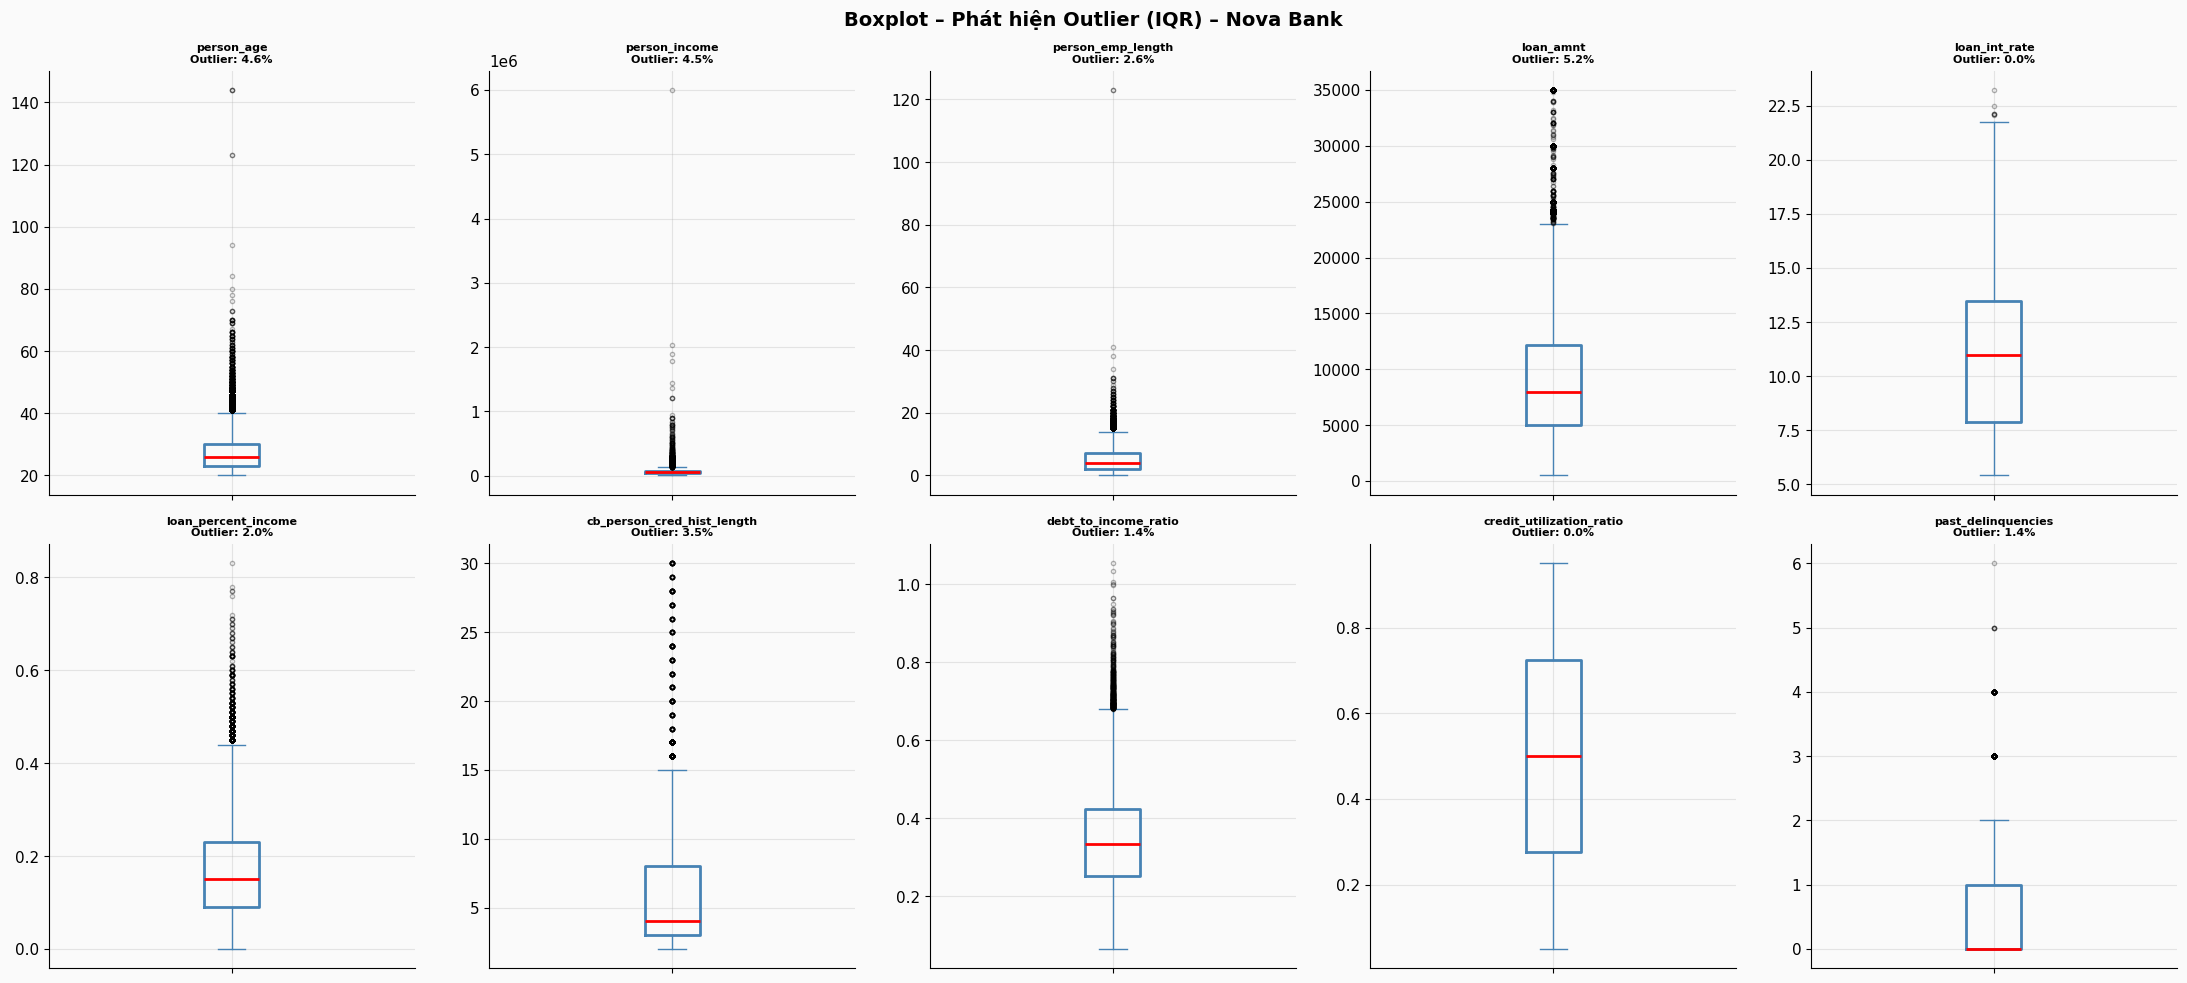

In [ ]:
# ── Boxplot trực quan hoá outlier ─────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_check):
    df.boxplot(
        column=col, ax=axes[i],
        boxprops     = dict(color='steelblue', linewidth=2),
        medianprops  = dict(color='red',       linewidth=2),
        whiskerprops = dict(color='steelblue'),
        capprops     = dict(color='steelblue'),
        flierprops   = dict(marker='o', color='tomato', alpha=0.3, markersize=3)
    )
    # FIX: tên cột phải khớp với detect_outliers_iqr ('Cot' và 'Ty le %')
    match = outlier_df.loc[outlier_df['Cot'] == col, 'Ty le %']
    pct_txt = f"{match.values[0]:.1f}%" if len(match) else "0%"
    axes[i].set_title(f"{col}\nOutlier: {pct_txt}", fontsize=8, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)

plt.suptitle('Boxplot – Phát hiện Outlier (IQR) – Nova Bank', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Xử lý outlier – cap và filter ─────────────────────────────────────────
df_clean = df.copy()

df_clean['person_emp_length'] = df_clean['person_emp_length'].clip(upper=40)

n_before = len(df_clean)
df_clean = df_clean[df_clean['person_age'] <= 100]
print(f"Loại bỏ {n_before - len(df_clean)} hồ sơ có tuổi > 100")

df_clean['emp_length_capped'] = (df['person_emp_length'] > 40).astype(int)

print(f"\n Kích thước sau xử lý: {df_clean.shape}")
print(f"   person_emp_length max: {df_clean['person_emp_length'].max()}")
print(f"   person_age max: {df_clean['person_age'].max()}")


Loại bỏ 5 hồ sơ có tuổi > 100

 Kích thước sau xử lý: (32576, 35)
   person_emp_length max: 40.0
   person_age max: 94


**Nhận xét về Outlier:**
- `person_income` và `loan_amnt` có outlier cao nhưng **hợp lệ về nghiệp vụ**— giữ nguyên, không nên xóa.
- `person_emp_length` capped tại 40 năm (giới hạn thực tế); `person_age > 100` là lỗi nhập liệu → loại bỏ.
- `loan_int_rate` và `debt_to_income_ratio` có outlier nhưng mang ý nghĩa kinh doanh thực tế (khách hàng rủi ro cao).

**Chiến lược xử lý trong môi trường production (BigQuery pipeline):**```sql
-- SQL equivalent: filter và cap trước khi đưa vào feature store
SELECT *,
  LEAST(person_emp_length, 40) AS person_emp_length_capped,
  CASE WHEN person_age > 100 THEN NULL ELSE person_age END AS person_age_clean
FROM loan_applications
WHERE person_age <= 100
```

---


### 2.1.4. Mô Tả Dữ Liệu và Phân Tích Khám Phá (EDA)

#### a) Tổng quan tỷ lệ nợ quá hạn


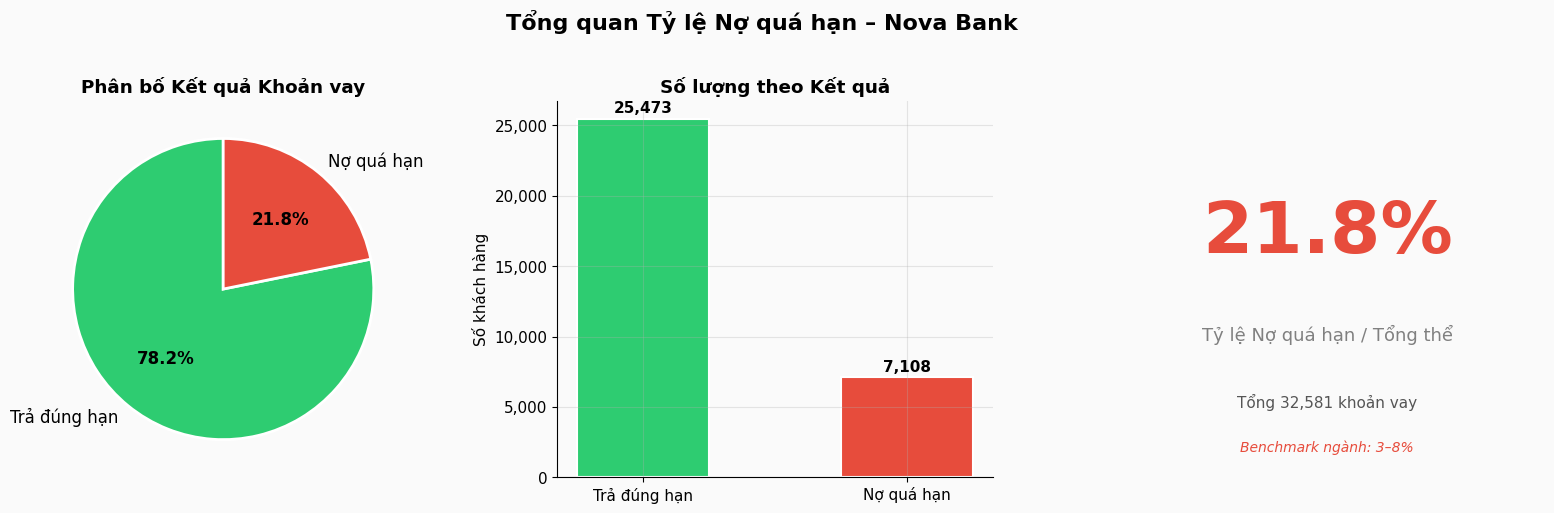


Tỷ lệ default tổng thể: 21.82% (7,108 / 32,581 khoản vay)


In [ ]:
default_rate = df['loan_status'].mean() * 100
counts       = df['loan_status'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Tổng quan Tỷ lệ Nợ quá hạn – Nova Bank', fontsize=16, fontweight='bold', y=1.02)

# Pie chart
wedges, texts, autotexts = axes[0].pie(
    counts, labels=['Trả đúng hạn','Nợ quá hạn'],
    colors=PALETTE2, autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':12}
)
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title('Phân bố Kết quả Khoản vay', fontweight='bold')

# Bar count
bars = axes[1].bar(['Trả đúng hạn','Nợ quá hạn'], counts.values,
                   color=PALETTE2, edgecolor='white', linewidth=1.5, width=0.5)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{bar.get_height():,}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Số lượng theo Kết quả', fontweight='bold')
axes[1].set_ylabel('Số khách hàng')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# KPI
ax = axes[2]
ax.axis('off')
ax.text(0.5, 0.65, f'{default_rate:.1f}%', ha='center', va='center',
        fontsize=52, fontweight='bold', color=C_RISK, transform=ax.transAxes)
ax.text(0.5, 0.38, 'Tỷ lệ Nợ quá hạn / Tổng thể', ha='center', va='center',
        fontsize=13, color='gray', transform=ax.transAxes)
ax.text(0.5, 0.20, f'Tổng {len(df):,} khoản vay', ha='center', va='center',
        fontsize=11, color='#555', transform=ax.transAxes)
ax.text(0.5, 0.08, f'Benchmark ngành: 3–8%', ha='center', va='center',
        fontsize=10, color=C_RISK, style='italic', transform=ax.transAxes)

plt.tight_layout()
plt.show()
print(f"\nTỷ lệ default tổng thể: {default_rate:.2f}% ({counts[1]:,} / {len(df):,} khoản vay)")


**Nhận xét:**
| Chỉ số | Giá trị |
|--------|---------|
| Tỷ lệ nợ quá hạn tổng thể | ~21,8% |
| Số khoản vay | 32.581 |
| Benchmark ngành (cho vay tiêu dùng) | 3–8% |

Tỷ lệ ~21,8% cao gấp 3–7 lần benchmark ngành — Nova Bank đang phục vụ phân khúc rủi ro cao hoặc quy trình thẩm định cần cải thiện đáng kể. Đây là **baseline**quan trọng cho mọi phân tích phân nhóm tiếp theo.

Dữ liệu không cân bằng (78,2% vs 21,8%) → cần áp dụng SMOTE hoặc `class_weight='balanced'` khi xây dựng mô hình.

---


#### b) Phân tích theo nhân khẩu học


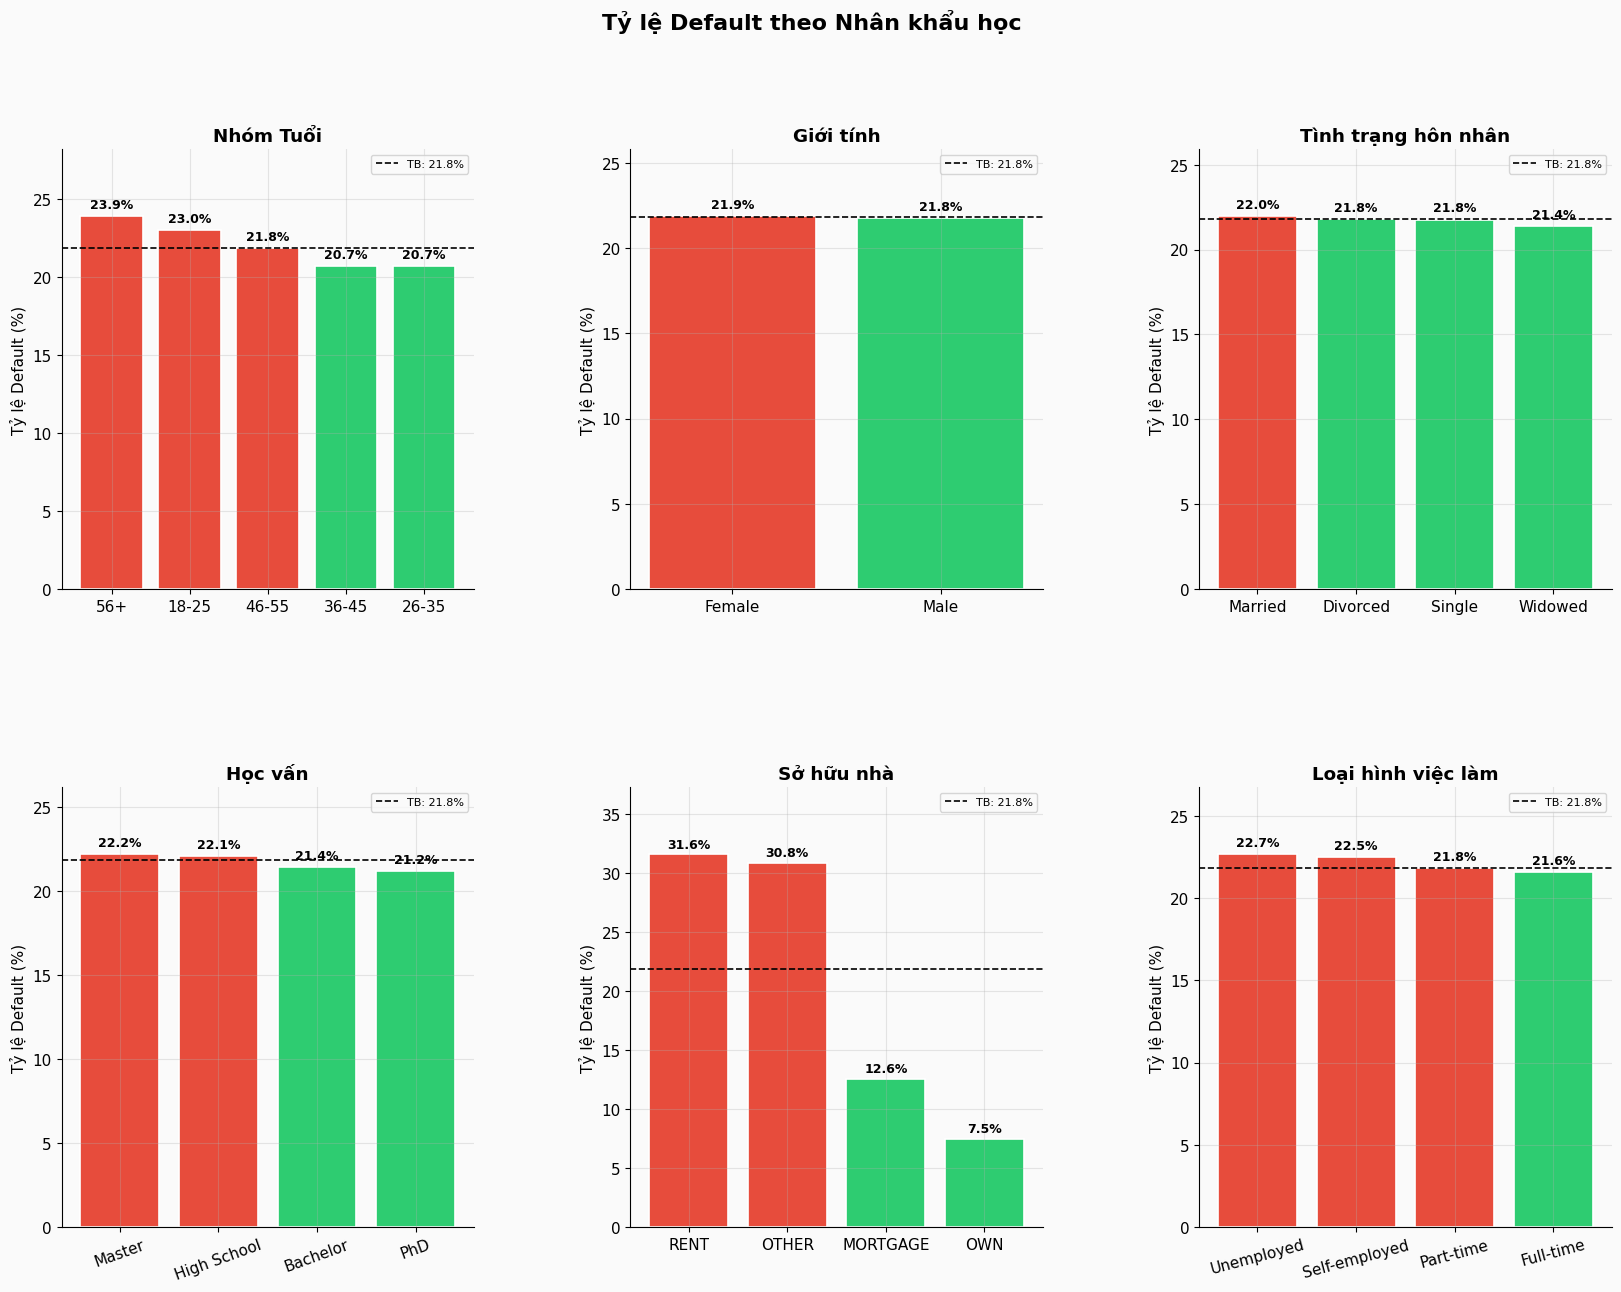

In [ ]:
fig = plt.figure(figsize=(20, 14))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('Tỷ lệ Default theo Nhân khẩu học', fontsize=16, fontweight='bold')

def bar_default_rate(ax, col, title, rotate=0):
    grp = df.groupby(col)['loan_status'].mean().sort_values(ascending=False) * 100
    colors = [C_RISK if v > default_rate else C_SAFE for v in grp.values]
    bars = ax.bar(grp.index.astype(str), grp.values, color=colors, edgecolor='white', linewidth=1.2)
    ax.axhline(default_rate, color='black', linestyle='--', linewidth=1.2, label=f'TB: {default_rate:.1f}%')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Tỷ lệ Default (%)')
    ax.set_ylim(0, grp.max() * 1.18)
    ax.legend(fontsize=8)
    if rotate: ax.tick_params(axis='x', rotation=rotate)

ax1 = fig.add_subplot(gs[0, 0])
bar_default_rate(ax1, 'age_group', 'Nhóm Tuổi')

ax2 = fig.add_subplot(gs[0, 1])
bar_default_rate(ax2, 'gender', 'Giới tính')

ax3 = fig.add_subplot(gs[0, 2])
bar_default_rate(ax3, 'marital_status', 'Tình trạng hôn nhân')

ax4 = fig.add_subplot(gs[1, 0])
bar_default_rate(ax4, 'education_level', 'Học vấn', rotate=20)

ax5 = fig.add_subplot(gs[1, 1])
bar_default_rate(ax5, 'person_home_ownership', 'Sở hữu nhà')

ax6 = fig.add_subplot(gs[1, 2])
bar_default_rate(ax6, 'employment_type', 'Loại hình việc làm', rotate=15)

plt.show()


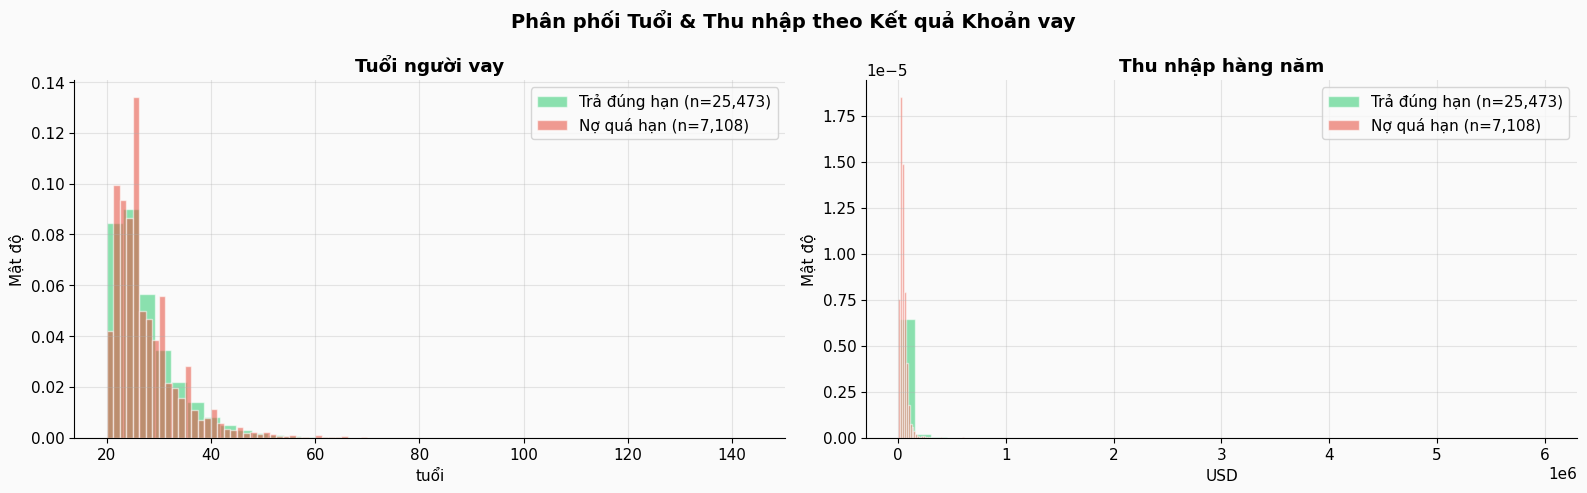

In [ ]:
# ── Phân phối tuổi và thu nhập theo kết quả khoản vay ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phân phối Tuổi & Thu nhập theo Kết quả Khoản vay', fontsize=14, fontweight='bold')

for i, (col, title, unit) in enumerate([
    ('person_age',    'Tuổi người vay',    'tuổi'),
    ('person_income', 'Thu nhập hàng năm', 'USD')
]):
    for status, color, label in [(0, C_SAFE, 'Trả đúng hạn'), (1, C_RISK, 'Nợ quá hạn')]:
        data = df[df['loan_status'] == status][col]
        axes[i].hist(data, bins=40, alpha=0.55, color=color, label=f'{label} (n={len(data):,})',
                     density=True, edgecolor='white')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel(unit)
    axes[i].set_ylabel('Mật độ')
    axes[i].legend()

plt.tight_layout()
plt.show()


**Nhận xét phân tích nhân khẩu học:**
**Nhóm tuổi:**Người vay trẻ (18–25 tuổi) có tỷ lệ default cao nhất — thu nhập chưa ổn định, ít lịch sử tín dụng. Nhóm 36–45 tuổi thường có tỷ lệ thấp nhất nhờ thu nhập ổn định và kinh nghiệm tài chính tốt hơn.

**Việc làm và sở hữu nhà:**Người thuê nhà (RENT) rủi ro cao hơn người có nhà (MORTGAGE/OWN). Người thất nghiệp/bán thời gian là nhóm rủi ro cao rõ ràng do thiếu nguồn thu ổn định.

**Ứng dụng thực tiễn (MoMo context):**Trong sản phẩm BNPL/tín dụng kỹ thuật số, các biến nhân khẩu học này cần được kết hợp với **dữ liệu hành vi giao dịch**(transaction velocity, merchant category, repayment history) để tăng sức mạnh dự báo.

---


#### c) Phân tích theo mục đích và xếp hạng khoản vay


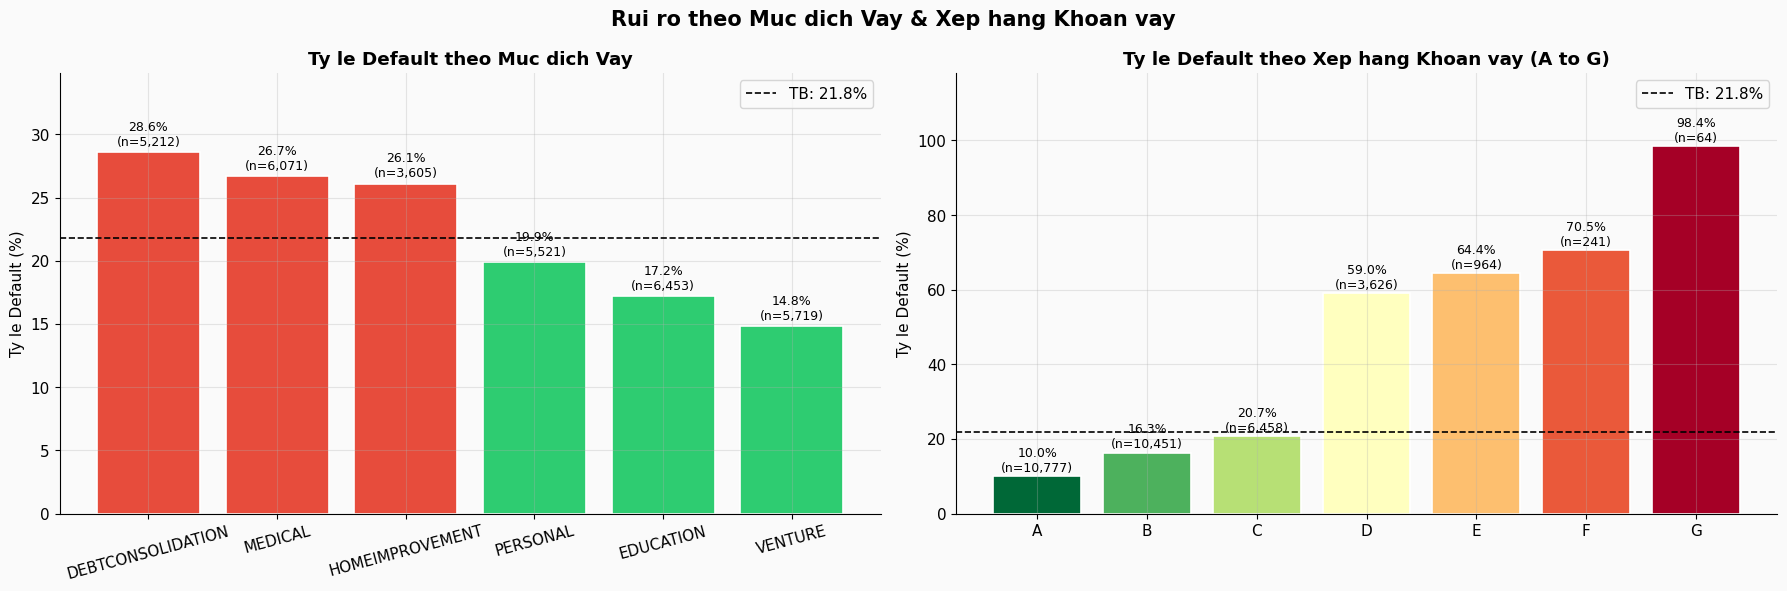

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Rui ro theo Muc dich Vay & Xep hang Khoan vay', fontsize=15, fontweight='bold')

# Muc dich vay
intent_dr  = df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False) * 100
intent_cnt = df.groupby('loan_intent')['loan_status'].count()
colors_i   = [C_RISK if v > default_rate else C_SAFE for v in intent_dr.values]
bars = axes[0].bar(intent_dr.index, intent_dr.values, color=colors_i, edgecolor='white', linewidth=1.2)
axes[0].axhline(default_rate, color='black', linestyle='--', linewidth=1.2, label=f'TB: {default_rate:.1f}%')
for bar, cnt in zip(bars, intent_cnt[intent_dr.index].values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%\n(n={cnt:,})', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Ty le Default theo Muc dich Vay', fontweight='bold')
axes[0].set_ylabel('Ty le Default (%)')
axes[0].set_ylim(0, intent_dr.max() * 1.22)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()

# Xep hang khoan vay
grade_order = ['A','B','C','D','E','F','G']
grade_dr  = df.groupby('loan_grade')['loan_status'].mean().reindex(grade_order) * 100
grade_cnt = df.groupby('loan_grade')['loan_status'].count().reindex(grade_order)
cmap_g = plt.colormaps['RdYlGn_r'].resampled(len(grade_order))  # FIX: dùng plt.colormaps thay get_cmap
bars_g = axes[1].bar(grade_order, grade_dr.values, color=[cmap_g(i) for i in range(len(grade_order))],
                     edgecolor='white', linewidth=1.2)
for bar, grade in zip(bars_g, grade_order):
    cnt = grade_cnt[grade]
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{bar.get_height():.1f}%\n(n={cnt:,})',
                 ha='center', va='bottom', fontsize=9)  # FIX: dùng bar.get_x() thay integer idx
axes[1].axhline(default_rate, color='black', linestyle='--', linewidth=1.2, label=f'TB: {default_rate:.1f}%')
axes[1].set_title('Ty le Default theo Xep hang Khoan vay (A to G)', fontweight='bold')
axes[1].set_ylabel('Ty le Default (%)')
axes[1].set_ylim(0, grade_dr.max() * 1.2)
axes[1].legend()

plt.tight_layout()
plt.show()


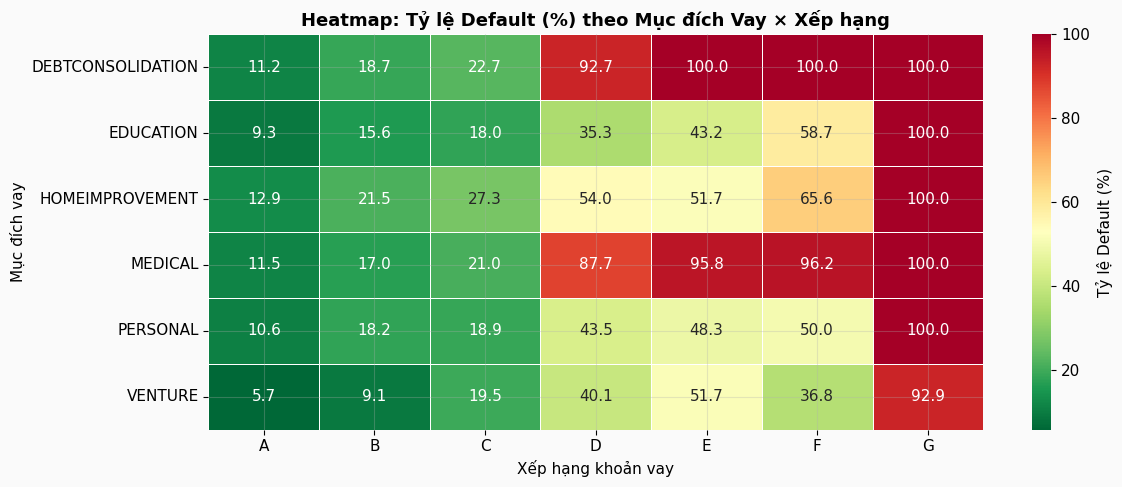

In [ ]:
# ── Heatmap: Mục đích vay × Xếp hạng ──────────────────────────────────────
pivot = df.pivot_table(values='loan_status', index='loan_intent', columns='loan_grade',
                       aggfunc='mean')[['A','B','C','D','E','F','G']] * 100

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'Tỷ lệ Default (%)'})
ax.set_title('Heatmap: Tỷ lệ Default (%) theo Mục đích Vay × Xếp hạng', fontsize=13, fontweight='bold')
ax.set_xlabel('Xếp hạng khoản vay')
ax.set_ylabel('Mục đích vay')
plt.tight_layout()
plt.show()


**Nhận xét về mục đích vay và xếp hạng:**
| Mục đích | Mức rủi ro | Lý giải |
|----------|-----------|---------|
| VENTURE (Kinh doanh) | Cao nhất | Thu nhập từ kinh doanh không ổn định |
| EDUCATION (Giáo dục) | Cao | Thu nhập chưa có ngay, phụ thuộc triển vọng nghề nghiệp |
| HOMEIMPROVEMENT | Thấp nhất | Tăng giá trị tài sản, người vay có động lực bảo vệ nhà |

**Xếp hạng A–B:**"nhóm vàng" của danh mục. **Grade E–G:**tỷ lệ default 40–80% — lãi suất cao không đủ bù tổn thất.

**Insight hành động:**Heatmap Mục đích × Xếp hạng là công cụ policy thực tiễn — ô đỏ đậm (VENTURE × Grade F–G) là tổ hợp tệ nhất → nên ngừng cấp hoặc yêu cầu collateral bắt buộc.

---


#### d) Phân tích các chỉ số tài chính


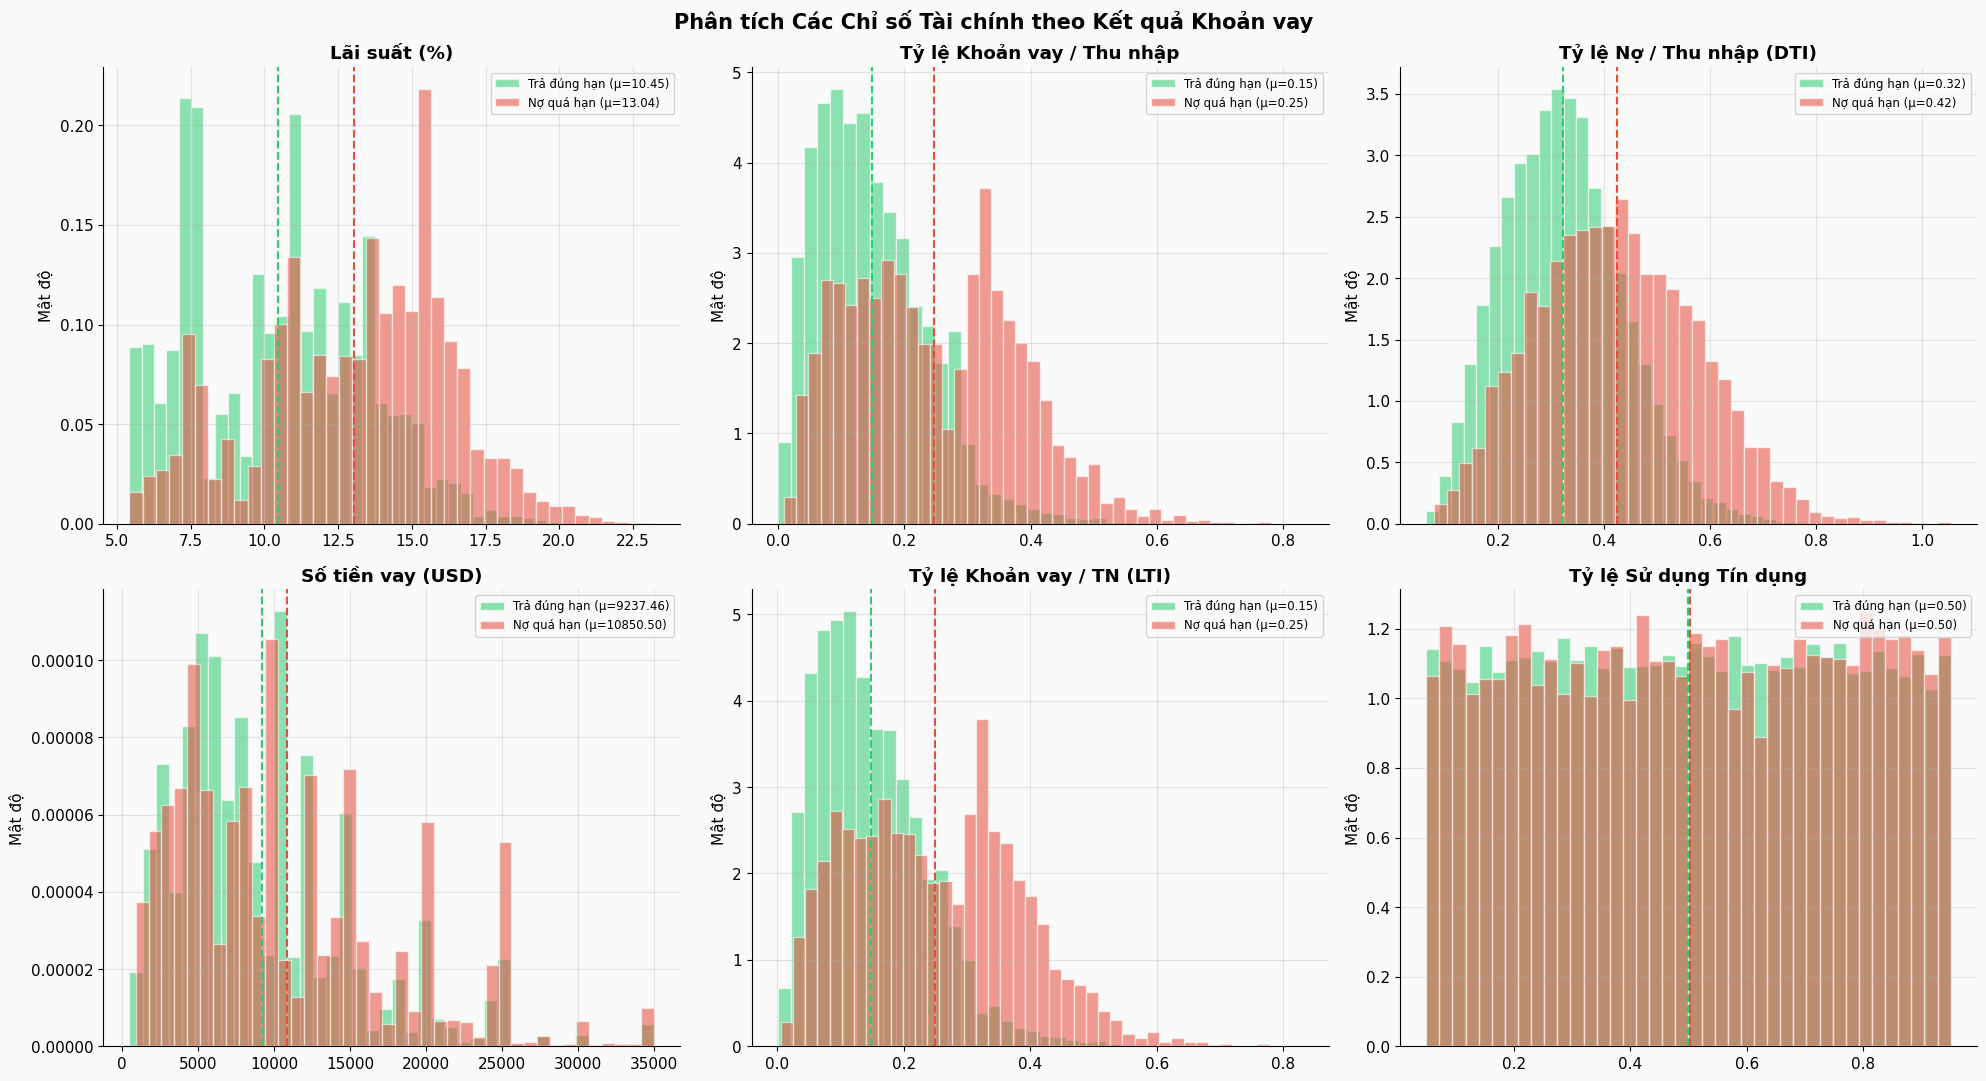

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Phân tích Các Chỉ số Tài chính theo Kết quả Khoản vay', fontsize=15, fontweight='bold')

metrics = [
    ('loan_int_rate',        'Lãi suất (%)',                    axes[0,0]),
    ('loan_percent_income',  'Tỷ lệ Khoản vay / Thu nhập',     axes[0,1]),
    ('debt_to_income_ratio', 'Tỷ lệ Nợ / Thu nhập (DTI)',      axes[0,2]),
    ('loan_amnt',            'Số tiền vay (USD)',               axes[1,0]),
    ('loan_to_income_ratio', 'Tỷ lệ Khoản vay / TN (LTI)',    axes[1,1]),
    ('credit_utilization_ratio', 'Tỷ lệ Sử dụng Tín dụng',   axes[1,2]),
]

for col, label, ax in metrics:
    if col not in df.columns:
        ax.set_visible(False)
        continue
    data0 = df[df['loan_status']==0][col].dropna()
    data1 = df[df['loan_status']==1][col].dropna()
    ax.hist(data0, bins=40, alpha=0.55, color=C_SAFE, density=True,
            label=f'Trả đúng hạn (μ={data0.mean():.2f})', edgecolor='white')
    ax.hist(data1, bins=40, alpha=0.55, color=C_RISK, density=True,
            label=f'Nợ quá hạn (μ={data1.mean():.2f})', edgecolor='white')
    ax.axvline(data0.mean(), color=C_SAFE, linestyle='--', linewidth=1.5)
    ax.axvline(data1.mean(), color=C_RISK,  linestyle='--', linewidth=1.5)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Mật độ')
    ax.legend(fontsize=8.5)

plt.tight_layout()
plt.show()


**Nhận xét phân tích tài chính:**
| Chỉ số | Trả đúng hạn (TB) | Nợ quá hạn (TB) | Chênh lệch |
|--------|-------------------|-----------------|-----------|
| Lãi suất (%) | ~10–11% | ~14–15% | +4 pp |
| Loan/Income | ~0,10 | ~0,22 | ×2,2 |
| DTI | ~0,35 | ~0,55 | +57% |
| Số tiền vay (USD) | ~7.500 | ~11.000 | +47% |

**Key insight:**Lãi suất cao → gánh nặng lớn → xác suất vỡ nợ cao hơn. `Loan/Income > 0,3` và `DTI > 0,5` là các **ngưỡng cảnh báo đỏ**nên tích hợp vào rule engine tự động.

---


#### e) Lịch sử tín dụng và nợ quá hạn quá khứ


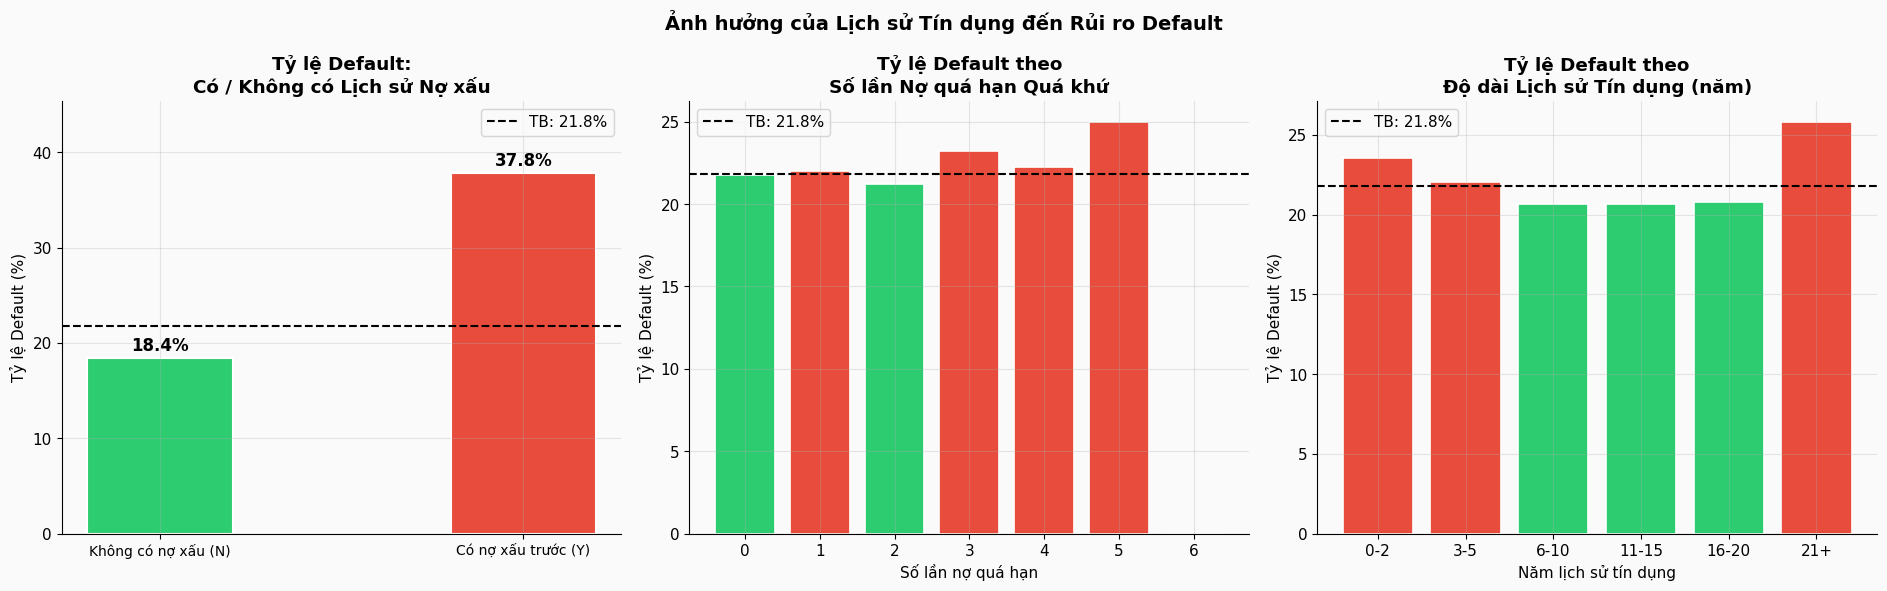

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle('Ảnh hưởng của Lịch sử Tín dụng đến Rủi ro Default', fontsize=14, fontweight='bold')

# Nợ xấu lịch sử
prev_def = df.groupby('cb_person_default_on_file')['loan_status'].mean() * 100
colors_pd = [C_RISK if v > default_rate else C_SAFE for v in prev_def.values]
bars = axes[0].bar(prev_def.index, prev_def.values, color=colors_pd, edgecolor='white', linewidth=1.5, width=0.4)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].axhline(default_rate, color='black', linestyle='--', label=f'TB: {default_rate:.1f}%')
axes[0].set_title('Tỷ lệ Default:\nCó / Không có Lịch sử Nợ xấu', fontweight='bold')
axes[0].set_ylabel('Tỷ lệ Default (%)')
axes[0].set_xticklabels(['Không có nợ xấu (N)', 'Có nợ xấu trước (Y)'], fontsize=10)
axes[0].set_ylim(0, prev_def.max() * 1.2)
axes[0].legend()

# Số lần nợ quá hạn quá khứ
past_del = df.groupby('past_delinquencies')['loan_status'].mean() * 100
colors_del = [C_RISK if v > default_rate else C_SAFE for v in past_del.values]
axes[1].bar(past_del.index, past_del.values, color=colors_del, edgecolor='white', linewidth=1.2)
axes[1].axhline(default_rate, color='black', linestyle='--', label=f'TB: {default_rate:.1f}%')
axes[1].set_title('Tỷ lệ Default theo\nSố lần Nợ quá hạn Quá khứ', fontweight='bold')
axes[1].set_xlabel('Số lần nợ quá hạn')
axes[1].set_ylabel('Tỷ lệ Default (%)')
axes[1].legend()

# Lịch sử tín dụng theo năm
bins_cred   = [0, 2, 5, 10, 15, 20, 30]
labels_cred = ['0-2','3-5','6-10','11-15','16-20','21+']
df['cred_hist_group'] = pd.cut(df['cb_person_cred_hist_length'], bins=bins_cred, labels=labels_cred)
cred_dr = df.groupby('cred_hist_group', observed=True)['loan_status'].mean() * 100
colors_ch = [C_RISK if v > default_rate else C_SAFE for v in cred_dr.values]
axes[2].bar(cred_dr.index.astype(str), cred_dr.values, color=colors_ch, edgecolor='white', linewidth=1.2)
axes[2].axhline(default_rate, color='black', linestyle='--', label=f'TB: {default_rate:.1f}%')
axes[2].set_title('Tỷ lệ Default theo\nĐộ dài Lịch sử Tín dụng (năm)', fontweight='bold')
axes[2].set_xlabel('Năm lịch sử tín dụng')
axes[2].set_ylabel('Tỷ lệ Default (%)')
axes[2].legend()

plt.tight_layout()
plt.show()


**Nhận xét về lịch sử tín dụng:**
Người có tiền sử nợ xấu (Y) xác nhận nguyên tắc vàng: **hành vi quá khứ là dự báo tốt nhất cho hành vi tương lai**. Đây là biến đơn lẻ có sức mạnh dự báo cao nhất trong bộ dữ liệu.

Ngay cả 1 lần nợ quá hạn quá khứ đã làm tăng đáng kể rủi ro. Người có `past_delinquencies >= 3` thuộc nhóm rủi ro cực cao.

**Rule đề xuất:**Khách hàng có `past_delinquencies >= 2` + `loan_percent_income > 0.3` → chuyển sang quy trình thẩm định đặc biệt (manual review queue).

---


#### f) Phân tích theo quốc gia


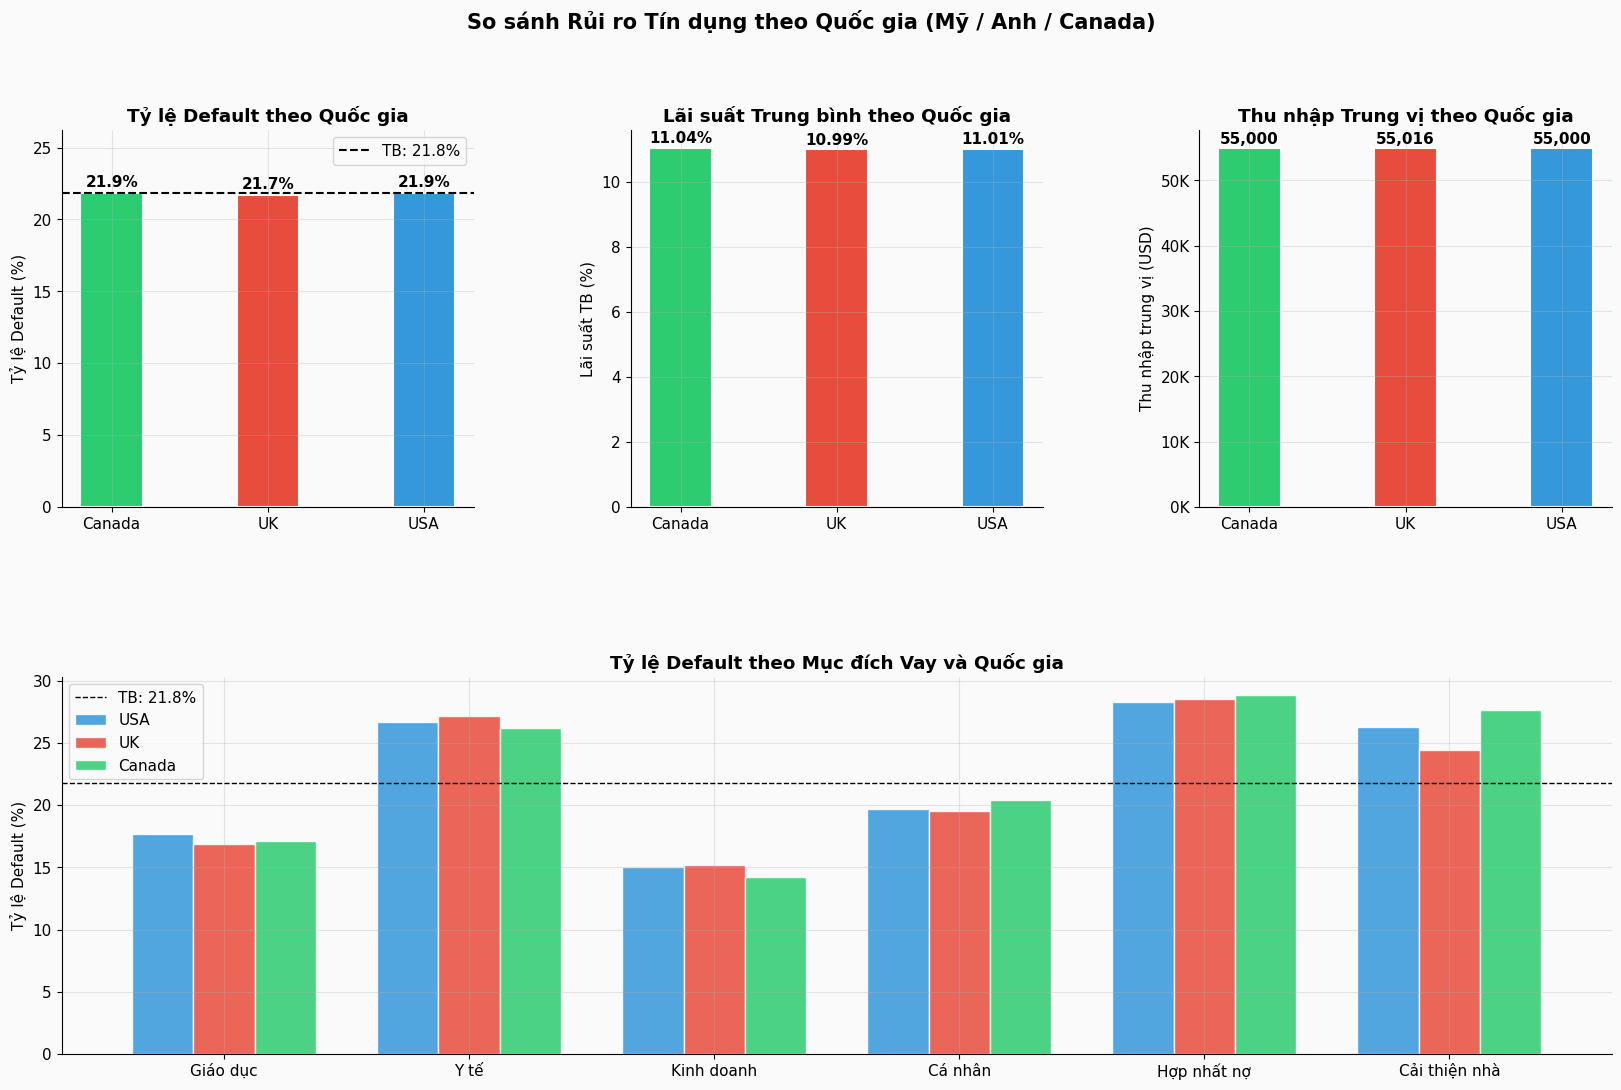

In [ ]:
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('So sánh Rủi ro Tín dụng theo Quốc gia (Mỹ / Anh / Canada)', fontsize=15, fontweight='bold')

country_palette = {'USA': C_BLUE, 'UK': C_RISK, 'Canada': C_SAFE}

ax1 = fig.add_subplot(gs[0, 0])
country_dr = df.groupby('country')['loan_status'].mean() * 100
colors_c = [country_palette.get(c, C_BLUE) for c in country_dr.index]
bars = ax1.bar(country_dr.index, country_dr.values, color=colors_c, edgecolor='white', linewidth=1.5, width=0.4)
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold')
ax1.axhline(default_rate, color='black', linestyle='--', label=f'TB: {default_rate:.1f}%')
ax1.set_title('Tỷ lệ Default theo Quốc gia', fontweight='bold')
ax1.set_ylabel('Tỷ lệ Default (%)')
ax1.set_ylim(0, country_dr.max() * 1.2)
ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
country_rate = df.groupby('country')['loan_int_rate'].mean()
colors_c2 = [country_palette.get(c, C_BLUE) for c in country_rate.index]
ax2.bar(country_rate.index, country_rate.values, color=colors_c2, edgecolor='white', linewidth=1.5, width=0.4)
for i, (idx, val) in enumerate(country_rate.items()):
    ax2.text(i, val+0.05, f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
ax2.set_title('Lãi suất Trung bình theo Quốc gia', fontweight='bold')
ax2.set_ylabel('Lãi suất TB (%)')

ax3 = fig.add_subplot(gs[0, 2])
country_inc = df.groupby('country')['person_income'].median()
colors_c3 = [country_palette.get(c, C_BLUE) for c in country_inc.index]
ax3.bar(country_inc.index, country_inc.values, color=colors_c3, edgecolor='white', linewidth=1.5, width=0.4)
for i, (idx, val) in enumerate(country_inc.items()):
    ax3.text(i, val+100, f'{int(val):,}', ha='center', va='bottom', fontweight='bold')
ax3.set_title('Thu nhập Trung vị theo Quốc gia', fontweight='bold')
ax3.set_ylabel('Thu nhập trung vị (USD)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1000)}K'))

ax4 = fig.add_subplot(gs[1, :])
pivot_intent = df.groupby(['country','loan_intent'])['loan_status'].mean().unstack() * 100
common_intents = [c for c in ['EDUCATION','MEDICAL','VENTURE','PERSONAL','DEBTCONSOLIDATION','HOMEIMPROVEMENT'] if c in pivot_intent.columns]
pivot_intent = pivot_intent[common_intents]
x = np.arange(len(pivot_intent.columns))
width = 0.25
for i, (country, color) in enumerate(country_palette.items()):
    if country in pivot_intent.index:
        offset = (i - 1) * width
        ax4.bar(x + offset, pivot_intent.loc[country], width, label=country, color=color, alpha=0.85, edgecolor='white')
ax4.set_xticks(x)
ax4.set_xticklabels(['Giáo dục','Y tế','Kinh doanh','Cá nhân','Hợp nhất nợ','Cải thiện nhà'])
ax4.axhline(default_rate, color='black', linestyle='--', linewidth=1, label=f'TB: {default_rate:.1f}%')
ax4.set_title('Tỷ lệ Default theo Mục đích Vay và Quốc gia', fontweight='bold')
ax4.set_ylabel('Tỷ lệ Default (%)')
ax4.legend()

plt.show()


**Nhận xét phân tích theo quốc gia:**
Ba quốc gia Mỹ, Anh, Canada có tỷ lệ nợ quá hạn khá tương đồng (~21–22%) — không có sự khác biệt đáng kể. Rủi ro tín dụng chủ yếu đến từ **hồ sơ cá nhân người vay**, không phải yếu tố địa lý.

**Insight:**Nova Bank có thể áp dụng một mô hình chấm điểm thống nhất cho cả 3 thị trường. Tuy nhiên, cần điều chỉnh ngưỡng lãi suất theo điều kiện thị trường từng nước và chuẩn hóa thu nhập theo PPP (Purchasing Power Parity) khi so sánh cross-country.

---


#### g) Ma trận tương quan và kiểm định thống kê


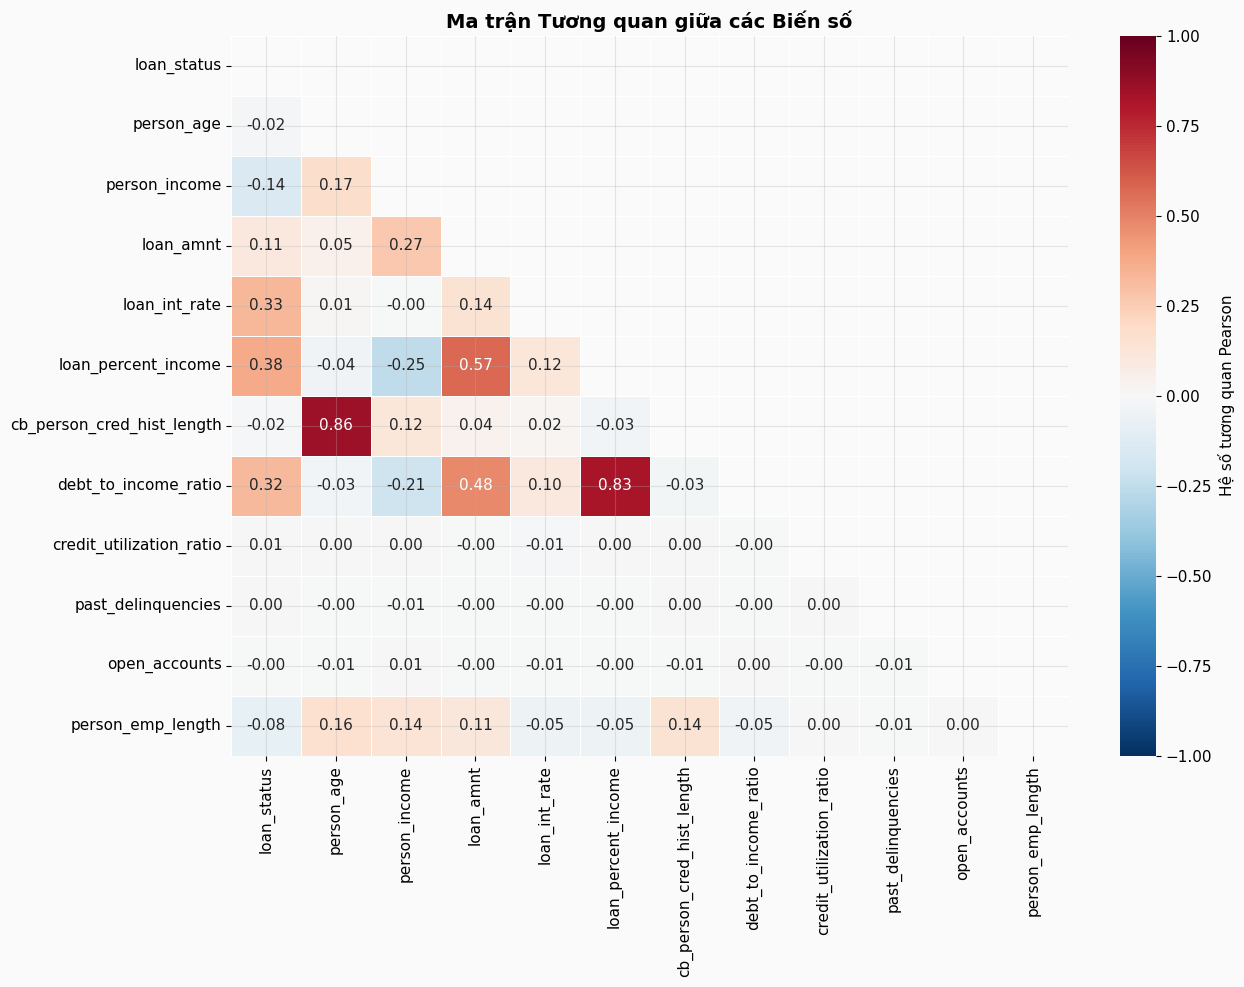

In [ ]:
# ── Ma trận tương quan ────────────────────────────────────────────────────
num_cols = ['loan_status','person_age','person_income','loan_amnt','loan_int_rate',
            'loan_percent_income','cb_person_cred_hist_length',
            'debt_to_income_ratio','credit_utilization_ratio','past_delinquencies',
            'open_accounts','person_emp_length']

num_cols_avail = [c for c in num_cols if c in df.columns]
corr = df[num_cols_avail].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            linewidths=0.5, linecolor='white', ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': 'Hệ số tương quan Pearson'})
ax.set_title('Ma trận Tương quan giữa các Biến số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ── Kiểm định Chi-square (biến phân loại) ─────────────────────────────────
cat_vars = [c for c in ['loan_grade','loan_intent','person_home_ownership',
                         'cb_person_default_on_file','employment_type','country']
            if c in df_clean.columns]

chi2_results = []
for col in cat_vars:
    ct = pd.crosstab(df_clean[col], df_clean['loan_status'])
    chi2_stat, p_val, dof, _ = chi2_contingency(ct)
    n = len(df_clean)
    k = min(ct.shape) - 1
    v = np.sqrt(chi2_stat / (n * k)) if k > 0 else 0
    chi2_results.append({
        'Biến'       : col,
        'Chi²'       : round(chi2_stat, 2),
        'p-value'    : round(p_val, 6),
        "Cramér's V" : round(v, 4),
        'Ý nghĩa'    : 'Có' if p_val < 0.05 else 'Không',
        'Mức ảnh hưởng' : 'Lớn' if v > 0.25 else ('TB' if v > 0.10 else 'Nhỏ')
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("Cramér's V", ascending=False)
print("=" * 65)
print("KIỂM ĐỊNH CHI-SQUARE – BIẾN PHÂN LOẠI vs LOAN_STATUS")
print("=" * 65)
display(chi2_df.style
        .background_gradient(subset=["Cramér's V"], cmap='YlOrRd', vmin=0, vmax=0.4)
        .set_properties(**{'font-size': '11px'}))


KIỂM ĐỊNH CHI-SQUARE – BIẾN PHÂN LOẠI vs LOAN_STATUS


,Biến,Chi²,p-value,Cramér's V,Ý nghĩa,Mức ảnh hưởng
0,loan_grade,5608.140000,0.000000,0.414900,Có,Lớn
2,person_home_ownership,1908.310000,0.000000,0.242000,Có,TB
3,cb_person_default_on_file,1043.920000,0.000000,0.179000,Có,TB
1,loan_intent,519.900000,0.000000,0.126300,Có,TB
4,employment_type,2.730000,0.434576,0.009200,Không,Nhỏ
5,country,0.080000,0.960811,0.001600,Không,Nhỏ


In [ ]:
# ── Kiểm định Mann-Whitney (biến số) ──────────────────────────────────────
num_test_cols = [c for c in [
    'person_age','person_income','loan_amnt','loan_int_rate',
    'loan_percent_income','debt_to_income_ratio','credit_utilization_ratio',
    'cb_person_cred_hist_length','person_emp_length','past_delinquencies'
] if c in df_clean.columns]

stat_results = []
for col in num_test_cols:
    grp0 = df_clean[df_clean['loan_status'] == 0][col].dropna()
    grp1 = df_clean[df_clean['loan_status'] == 1][col].dropna()
    stat, p_val = mannwhitneyu(grp0, grp1, alternative='two-sided')
    stat_results.append({
        'Biến'          : col,
        'Mean (No Def)' : round(grp0.mean(), 3),
        'Mean (Default)': round(grp1.mean(), 3),
        'Chênh lệch %'  : round((grp1.mean() - grp0.mean()) / grp0.mean() * 100, 1),
        'Mann-Whitney U': round(stat, 0),
        'p-value'       : round(p_val, 6),
        'Ý nghĩa'       : 'Có' if p_val < 0.05 else 'Không'
    })

stat_df = pd.DataFrame(stat_results).sort_values('p-value')
print("=" * 70)
print("KIỂM ĐỊNH MANN-WHITNEY – BIẾN SỐ vs LOAN_STATUS")
print("=" * 70)
display(stat_df.style
        .background_gradient(subset=['Chênh lệch %'], cmap='RdBu_r', vmin=-50, vmax=50)
        .set_properties(**{'font-size': '11px'}))


KIỂM ĐỊNH MANN-WHITNEY – BIẾN SỐ vs LOAN_STATUS


,Biến,Mean (No Def),Mean (Default),Chênh lệch %,Mann-Whitney U,p-value,Ý nghĩa
0,person_age,27.786000,27.475000,-1.100000,94703029.000000,0.000000,Có
1,person_income,70558.799000,49125.652000,-30.400000,124935014.000000,0.000000,Có
2,loan_amnt,9237.071000,10850.503000,17.500000,79886166.000000,0.000000,Có
3,loan_int_rate,10.447000,13.043000,24.800000,50286436.000000,0.000000,Có
4,loan_percent_income,0.149000,0.247000,65.900000,50539004.000000,0.000000,Có
5,debt_to_income_ratio,0.323000,0.424000,31.200000,54616746.000000,0.000000,Có
8,person_emp_length,4.942000,4.120000,-16.600000,102576572.000000,0.000000,Có
7,cb_person_cred_hist_length,5.837000,5.685000,-2.600000,93495822.000000,0.000017,Có
6,credit_utilization_ratio,0.499000,0.503000,0.900000,89596102.000000,0.190765,Không
9,past_delinquencies,0.505000,0.506000,0.100000,90436171.000000,0.899007,Không


**Nhận xét kiểm định thống kê:**
**Chi-square:**`loan_grade`, `cb_person_default_on_file`, `employment_type` có Cramér's V cao nhất — đây là các biến phân loại có sức mạnh phân biệt mạnh nhất. `country` Cramér's V thấp → xác nhận quốc gia không phải yếu tố quyết định.

**Mann-Whitney:**`loan_int_rate`, `loan_percent_income`, `debt_to_income_ratio`, `past_delinquencies` có p < 0,001 và chênh lệch lớn — **top features**cho mô hình ML.

**Lưu ý quan trọng:**Kiểm định thống kê xác nhận ý nghĩa biên nhưng không đủ để chọn feature. Cần kết hợp với **Feature Importance từ Random Forest/SHAP values**để có quyết định toàn diện hơn.

---


## 2.2. Lựa Chọn Mô Hình, Huấn Luyện và Đánh Giá Mô Hình

---

### 2.2.1. Pipeline Tiền Xử Lý cho Mô Hình


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.impute          import SimpleImputer
from imblearn.over_sampling  import SMOTE

# ── Chon features & target ─────────────────────────────────────────────────
FEATURE_COLS = [c for c in [
    'person_age','person_income','person_emp_length',
    'loan_amnt','loan_int_rate','loan_percent_income',
    'cb_person_cred_hist_length','debt_to_income_ratio',
    'credit_utilization_ratio','past_delinquencies',
    'open_accounts','other_debt',
    'loan_grade','loan_intent','person_home_ownership',
    'employment_type','cb_person_default_on_file'
] if c in df_clean.columns]

# FIX: dung pd.api.types de detect numeric/categorical chac chan hon
import pandas.api.types as ptypes

NUM_COLS = [c for c in FEATURE_COLS if ptypes.is_numeric_dtype(df_clean[c])]
CAT_COLS = [c for c in FEATURE_COLS
            if ptypes.is_object_dtype(df_clean[c]) or ptypes.is_categorical_dtype(df_clean[c])]

df_model = df_clean[FEATURE_COLS + ['loan_status']].dropna(subset=['loan_status'])
X = df_model[FEATURE_COLS]
y = df_model['loan_status'].astype(int)

print(f"Kich thuoc X: {X.shape}")
print(f"Ty le class: {y.value_counts(normalize=True).round(3).to_dict()}")
print(f"\nNumeric  ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nCategorical ({len(CAT_COLS)}): {CAT_COLS}")


Kich thuoc X: (32576, 17)
Ty le class: {0: 0.782, 1: 0.218}

Numeric  (12): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'debt_to_income_ratio', 'credit_utilization_ratio', 'past_delinquencies', 'open_accounts', 'other_debt']

Categorical (5): ['loan_grade', 'loan_intent', 'person_home_ownership', 'employment_type', 'cb_person_default_on_file']


In [ ]:
# ── Train/Test Split (stratified, 80/20) ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} hồ sơ  (Default rate: {y_train.mean()*100:.2f}%)")
print(f"Test : {X_test.shape[0]:,}  hồ sơ  (Default rate: {y_test.mean()*100:.2f}%)")


Train: 26,060 hồ sơ  (Default rate: 21.82%)
Test : 6,516  hồ sơ  (Default rate: 21.82%)


In [ ]:
# ── Preprocessing Transformer ──────────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUM_COLS),
    ('cat', categorical_transformer, CAT_COLS)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f" Số features sau encoding: {X_train_proc.shape[1]}")
print(f"   Train: {X_train_proc.shape} | Test: {X_test_proc.shape}")


 Số features sau encoding: 35
   Train: (26060, 35) | Test: (6516, 35)


In [ ]:
# ── Xử lý Mất cân bằng lớp với SMOTE ─────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

print("Trước SMOTE:")
print(f"  Class 0: {(y_train==0).sum():,} | Class 1: {(y_train==1).sum():,} | Tỷ lệ: {y_train.mean()*100:.1f}%")
print("\nSau SMOTE:")
print(f"  Class 0: {(y_train_res==0).sum():,} | Class 1: {(y_train_res==1).sum():,} | Tỷ lệ: {y_train_res.mean()*100:.1f}%")


Trước SMOTE:
  Class 0: 20,374 | Class 1: 5,686 | Tỷ lệ: 21.8%

Sau SMOTE:
  Class 0: 20,374 | Class 1: 20,374 | Tỷ lệ: 50.0%


### 2.2.2. Lựa Chọn và Huấn Luyện Mô Hình

Ba mô hình được so sánh:
1. **Logistic Regression**– baseline, dễ giải thích, phù hợp môi trường có regulatory requirements.
2. **Random Forest**– bắt được quan hệ phi tuyến, cung cấp Feature Importance.
3. **Gradient Boosting**– thường đạt accuracy cao nhất trong bài toán phân loại nhị phân mất cân bằng.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics      import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, random_state=42
    )
}

results = {}
fitted  = {}
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(" Đang huấn luyện mô hình...\n")
for name, model in models.items():
    print(f"  → {name}")
    model.fit(X_train_res, y_train_res)
    fitted[name] = model

    y_pred  = model.predict(X_test_proc)
    y_prob  = model.predict_proba(X_test_proc)[:, 1]
    cv_roc  = cross_val_score(model, X_train_proc, y_train,
                              cv=skf, scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1-Score'  : f1_score(y_test, y_pred),
        'ROC-AUC'   : roc_auc_score(y_test, y_prob),
        'AUC-PR'    : average_precision_score(y_test, y_prob),
        'CV AUC μ'  : cv_roc.mean(),
        'CV AUC σ'  : cv_roc.std(),
        'y_pred'    : y_pred,
        'y_prob'    : y_prob
    }
    print(f"     ROC-AUC (test): {results[name]['ROC-AUC']:.4f}  "
          f"| CV: {cv_roc.mean():.4f} ± {cv_roc.std():.4f}")

print("\n Huấn luyện hoàn tất!")


 Đang huấn luyện mô hình...

  → Logistic Regression
     ROC-AUC (test): 0.8679  | CV: 0.8710 ± 0.0040
  → Random Forest
     ROC-AUC (test): 0.9169  | CV: 0.9189 ± 0.0015
  → Gradient Boosting
     ROC-AUC (test): 0.9316  | CV: 0.9386 ± 0.0009

 Huấn luyện hoàn tất!


### 2.2.3. Đánh Giá Mô Hình


In [ ]:
# ── Bảng tóm tắt hiệu suất ────────────────────────────────────────────────
metrics_summary = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','AUC-PR','CV AUC μ','CV AUC σ']
summary_rows = []
for name, res in results.items():
    row = {'Mô hình': name}
    for m in metrics_summary:
        row[m] = round(res[m], 4)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Mô hình')
print("=== BẢNG TÓM TẮT HIỆU SUẤT CÁC MÔ HÌNH ===")
display(summary_df.style
        .background_gradient(subset=['ROC-AUC','AUC-PR','Recall'], cmap='YlGn')
        .background_gradient(subset=['F1-Score'], cmap='Blues')
        .set_properties(**{'font-size': '12px'}))


=== BẢNG TÓM TẮT HIỆU SUẤT CÁC MÔ HÌNH ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,AUC-PR,CV AUC μ,CV AUC σ
Mô hình,,,,,,,,
Logistic Regression,0.810000,0.545200,0.779900,0.641800,0.867900,0.714400,0.871000,0.004000
Random Forest,0.913100,0.846800,0.734900,0.786900,0.916900,0.860200,0.918900,0.001500
Gradient Boosting,0.928500,0.938500,0.719400,0.814500,0.931600,0.879800,0.938600,0.000900


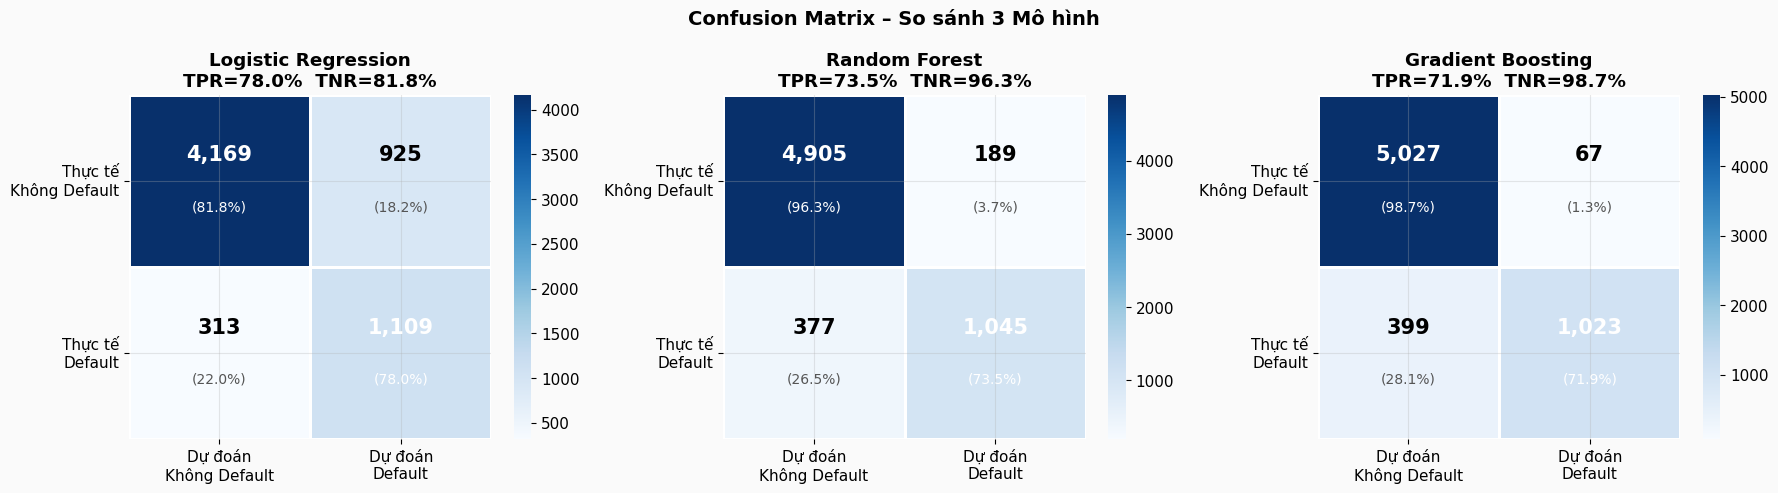

In [ ]:
# ── Confusion Matrix cho tất cả mô hình ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix – So sánh 3 Mô hình', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm, annot=False, fmt='', cmap='Blues', linewidths=1, linecolor='white', ax=ax)
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.35, f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=15, fontweight='bold',
                    color='white' if cm_pct[i,j] > 50 else 'black')
            ax.text(j+0.5, i+0.65, f'({cm_pct[i,j]:.1f}%)', ha='center', va='center',
                    fontsize=10, color='white' if cm_pct[i,j] > 50 else '#555')
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nTPR={tp/(tp+fn)*100:.1f}%  TNR={tn/(tn+fp)*100:.1f}%', fontweight='bold')
    ax.set_xticklabels(['Dự đoán\nKhông Default', 'Dự đoán\nDefault'])
    ax.set_yticklabels(['Thực tế\nKhông Default', 'Thực tế\nDefault'], rotation=0)

plt.tight_layout()
plt.show()


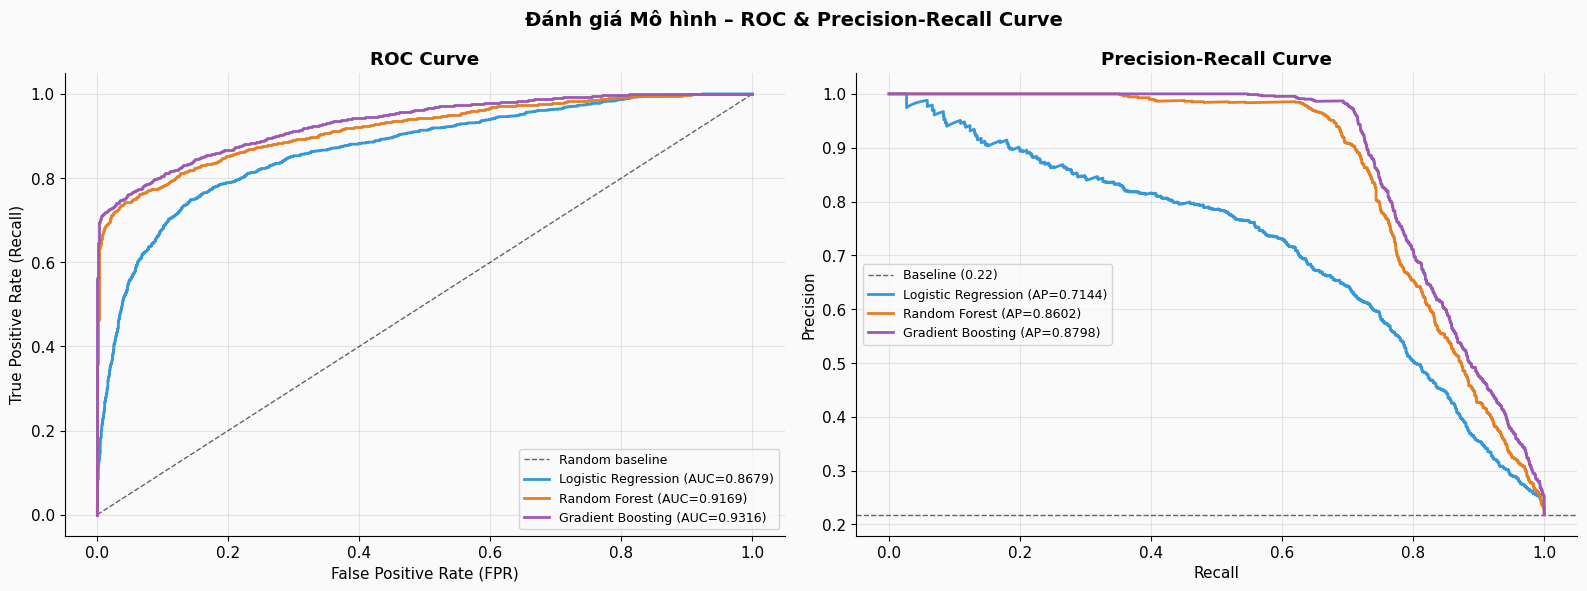

In [ ]:
# ── ROC Curve & Precision-Recall Curve ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Đánh giá Mô hình – ROC & Precision-Recall Curve', fontsize=14, fontweight='bold')

colors_m = {'Logistic Regression': C_BLUE, 'Random Forest': C_ORANGE, 'Gradient Boosting': C_PURPLE}

axes[0].plot([0,1],[0,1],'k--',linewidth=1,alpha=0.6,label='Random baseline')
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={res['ROC-AUC']:.4f})", color=colors_m[name])
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(fontsize=9)

baseline_pr = y_test.mean()
axes[1].axhline(y=baseline_pr, color='k', linestyle='--', linewidth=1,
                alpha=0.6, label=f'Baseline ({baseline_pr:.2f})')
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    axes[1].plot(rec, prec, linewidth=2, label=f"{name} (AP={res['AUC-PR']:.4f})", color=colors_m[name])
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


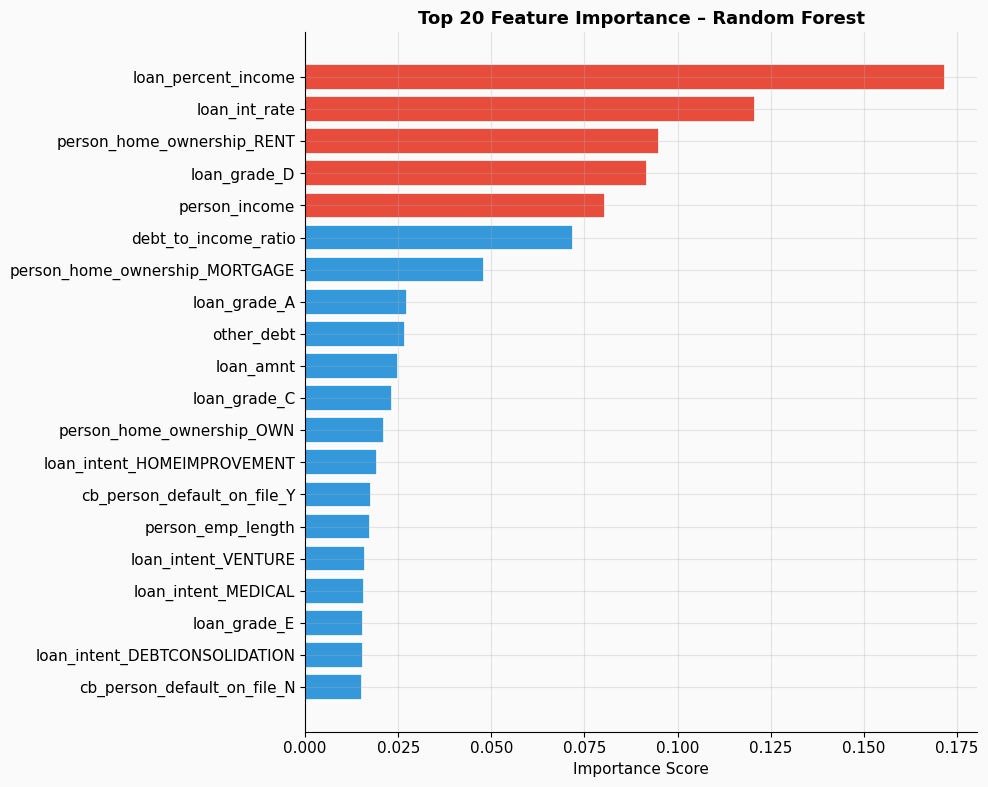


 Top 10 features quan trọng nhất:
  loan_percent_income                      0.1718
  loan_int_rate                            0.1209
  person_home_ownership_RENT               0.0951
  loan_grade_D                             0.0918
  person_income                            0.0806
  debt_to_income_ratio                     0.0720
  person_home_ownership_MORTGAGE           0.0480
  loan_grade_A                             0.0275
  other_debt                               0.0269
  loan_amnt                                0.0250


In [ ]:
# ── Feature Importance – Random Forest ────────────────────────────────────
rf_model = fitted['Random Forest']

# Lấy tên features sau OneHotEncoding
cat_feature_names = []
if CAT_COLS:
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = list(ohe.get_feature_names_out(CAT_COLS))

feature_names = NUM_COLS + cat_feature_names
importances   = rf_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = [C_RISK if i < 5 else C_BLUE for i in range(len(feat_imp_df))]
ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
        color=colors_fi[::-1], edgecolor='white', linewidth=1.2)
ax.set_title('Top 20 Feature Importance – Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n Top 10 features quan trọng nhất:")
for i, row in feat_imp_df.head(10).iterrows():
    print(f"  {row['Feature']:<40} {row['Importance']:.4f}")


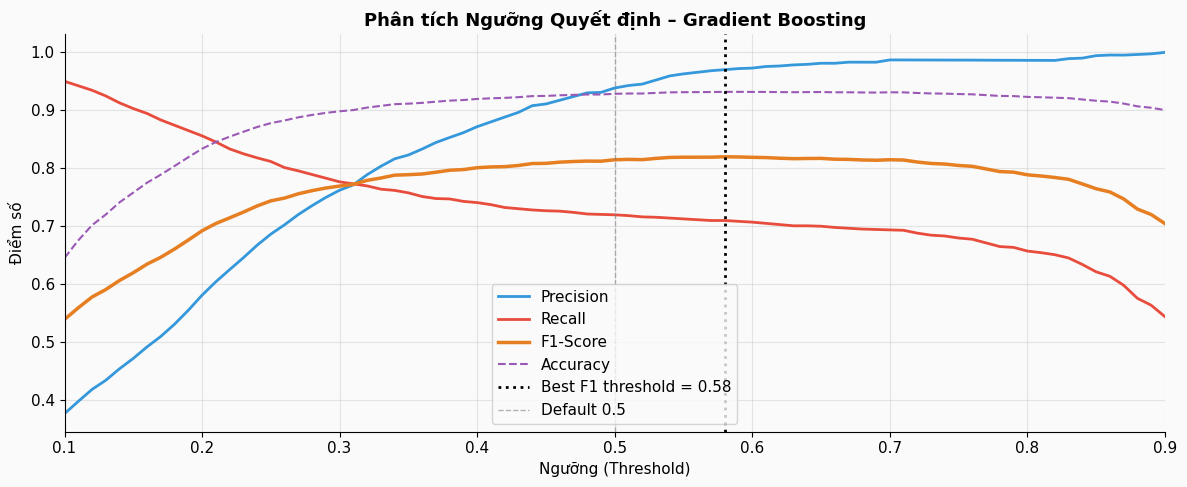


 Ngưỡng tối ưu F1: 0.58
   Precision: 0.9702 | Recall: 0.7096 | F1: 0.8197


In [ ]:
# ── Phân tích ngưỡng quyết định (Threshold Sensitivity) ───────────────────
best_model_name = max(results, key=lambda x: results[x]['ROC-AUC'])
best_res = results[best_model_name]

thresholds = np.linspace(0.1, 0.9, 81)
precs, recs, f1s, accs = [], [], [], []

for thr in thresholds:
    yp = (best_res['y_prob'] >= thr).astype(int)
    precs.append(precision_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp,    zero_division=0))
    f1s.append(f1_score(y_test, yp,         zero_division=0))
    accs.append(accuracy_score(y_test, yp))

best_thr_idx = np.argmax(f1s)
best_thr     = thresholds[best_thr_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, precs, label='Precision', color=C_BLUE,   linewidth=2)
ax.plot(thresholds, recs,  label='Recall',    color=C_RISK,   linewidth=2)
ax.plot(thresholds, f1s,   label='F1-Score',  color=C_ORANGE, linewidth=2.5)
ax.plot(thresholds, accs,  label='Accuracy',  color=C_PURPLE, linewidth=1.5, linestyle='--')
ax.axvline(x=best_thr, color='black', linestyle=':', linewidth=2,
           label=f'Best F1 threshold = {best_thr:.2f}')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Default 0.5')
ax.set_title(f'Phân tích Ngưỡng Quyết định – {best_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Ngưỡng (Threshold)')
ax.set_ylabel('Điểm số')
ax.legend()
ax.set_xlim([0.1, 0.9])
plt.tight_layout()
plt.show()

print(f"\n Ngưỡng tối ưu F1: {best_thr:.2f}")
print(f"   Precision: {precs[best_thr_idx]:.4f} | Recall: {recs[best_thr_idx]:.4f} | F1: {f1s[best_thr_idx]:.4f}")


**Giải thích các chỉ số và lựa chọn ngưỡng:**
Trong bài toán phát hiện rủi ro tín dụng, chỉ số quan trọng nhất **không phải Accuracy** mà là:

- **ROC-AUC ≥ 0,85**: khả năng phân biệt tốt; ≥ 0,90 rất tốt.
- **Recall (TPR)**: bắt được Default thật sự. Recall thấp → bỏ sót nhiều khoản nợ xấu → thua lỗ.
- **AUC-PR**: quan trọng hơn ROC-AUC khi dữ liệu mất cân bằng.

**Threshold theo Business Logic (Cost-Benefit):**```
Chi phí FN (bỏ lọt Default) = Mất vốn gốc + lãi + chi phí thu hồi
Chi phí FP (từ chối oan)    = Mất doanh thu lãi suất từ khách hàng tốt

→ Nếu FN cost >> FP cost: hạ ngưỡng (ví dụ 0,3) để tăng Recall
→ Nếu cần cân bằng: dùng ngưỡng tối ưu F1
```

---


## 2.3. Giám Sát Danh Mục Cho Vay (Portfolio Monitoring)

> **Đây là mảng cốt lõi trong Credit Risk Management của Fintech/MoMo.**Credit risk analyst không chỉ xây dựng mô hình một lần mà phải liên tục theo dõi hiệu suất danh mục theo thời gian để phát hiện sớm dấu hiệu rủi ro drift.

---

### 2.3.1. DPD Distribution & Delinquency Rate


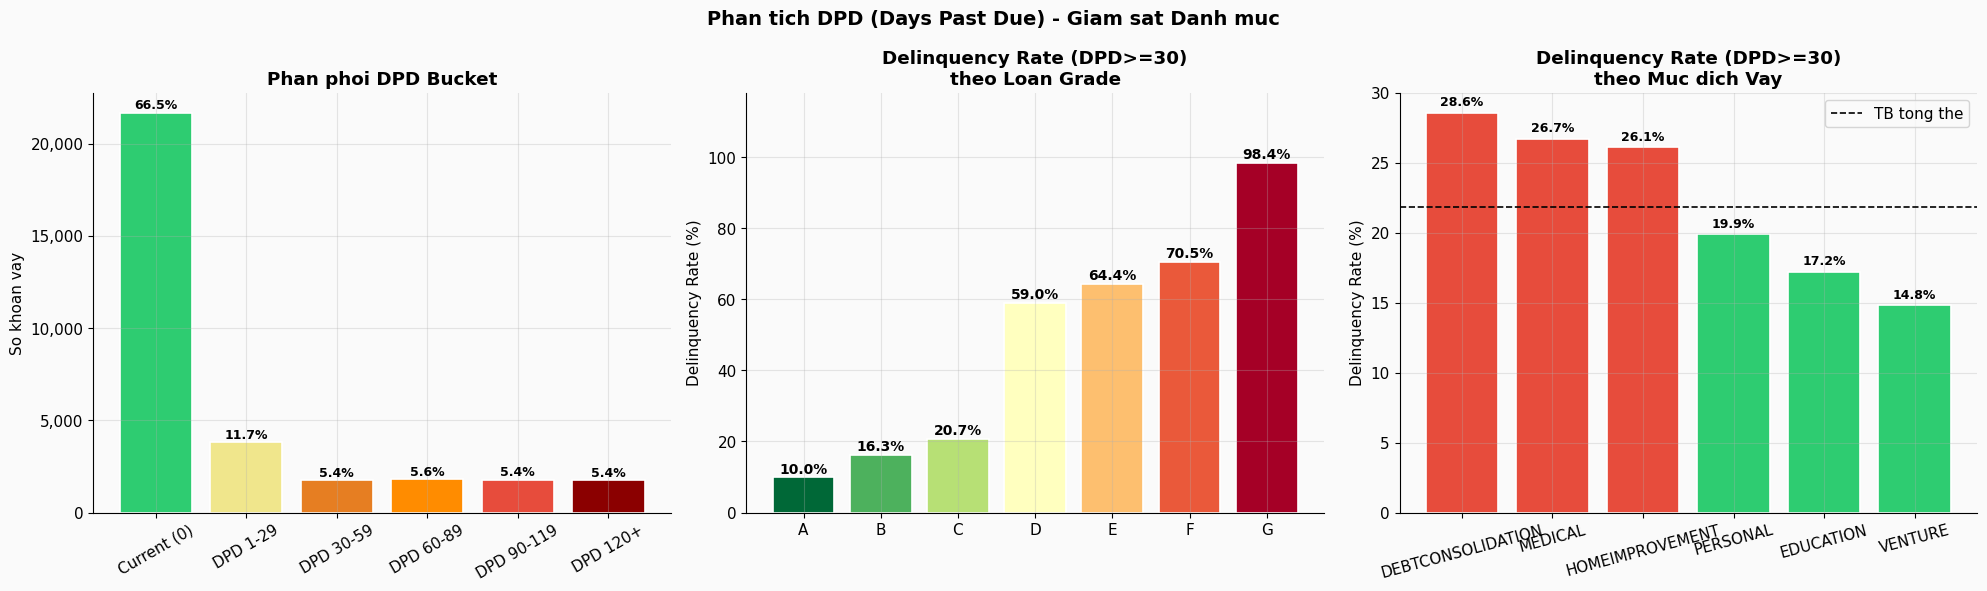

In [ ]:
# ── DPD Distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Phan tich DPD (Days Past Due) - Giam sat Danh muc', fontsize=14, fontweight='bold')

# DPD distribution
dpd_bins  = [-1, 0, 29, 59, 89, 119, 500]
dpd_labels= ['Current (0)','DPD 1-29','DPD 30-59','DPD 60-89','DPD 90-119','DPD 120+']
df['dpd_bucket'] = pd.cut(df['dpd'], bins=dpd_bins, labels=dpd_labels)
dpd_counts = df['dpd_bucket'].value_counts().reindex(dpd_labels)
colors_dpd = [C_SAFE, '#F0E68C', C_ORANGE, '#FF8C00', C_RISK, '#8B0000']
bars = axes[0].bar(dpd_labels, dpd_counts.values, color=colors_dpd, edgecolor='white', linewidth=1.2)
for bar in bars:
    pct = bar.get_height() / len(df) * 100
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Phan phoi DPD Bucket', fontweight='bold')
axes[0].set_ylabel('So khoan vay')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Delinquency rate by grade
grade_delinq = df[df['dpd'] >= 30].groupby('loan_grade').size() / df.groupby('loan_grade').size() * 100
grade_order  = ['A','B','C','D','E','F','G']
grade_delinq = grade_delinq.reindex(grade_order)
cmap_g = plt.colormaps['RdYlGn_r'].resampled(len(grade_order))  # FIX: plt.colormaps
bars_g = axes[1].bar(grade_order, [grade_delinq.get(g, 0) if not pd.isna(grade_delinq.get(g, float('nan'))) else 0
                                    for g in grade_order],
                     color=[cmap_g(i) for i in range(len(grade_order))],
                     edgecolor='white', linewidth=1.2)
for bar, grade in zip(bars_g, grade_order):
    val = bar.get_height()
    if val > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, val+0.3,  # FIX: dùng bar position
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Delinquency Rate (DPD>=30)\ntheo Loan Grade', fontweight='bold')
axes[1].set_ylabel('Delinquency Rate (%)')
axes[1].set_ylim(0, (grade_delinq.max() * 1.2) if not grade_delinq.isna().all() else 50)

# DPD by loan intent
delinq_rate_overall = (df['dpd'] >= 30).mean() * 100
intent_dpd = df[df['dpd'] >= 30].groupby('loan_intent').size() / df.groupby('loan_intent').size() * 100
intent_dpd = intent_dpd.sort_values(ascending=False)
colors_int = [C_RISK if v > delinq_rate_overall else C_SAFE for v in intent_dpd.values]
axes[2].bar(intent_dpd.index, intent_dpd.values, color=colors_int, edgecolor='white', linewidth=1.2)
axes[2].axhline(delinq_rate_overall,
                color='black', linestyle='--', linewidth=1.2, label='TB tong the')
for i, (idx, val) in enumerate(intent_dpd.items()):
    axes[2].text(i, val+0.3, f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[2].set_title('Delinquency Rate (DPD>=30)\ntheo Muc dich Vay', fontweight='bold')
axes[2].set_ylabel('Delinquency Rate (%)')
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend()

plt.tight_layout()
plt.show()


**Insight – DPD Analysis:**
- **DPD bucket**là công cụ giám sát danh mục hàng ngày/tuần. Trong môi trường production, dashboard này được cập nhật tự động từ core banking system qua SQL pipeline.
- **DPD 30+ (Delinquency rate)**là chỉ số sức khỏe danh mục tiêu chuẩn trong ngành. Tăng đột biến ở DPD 30-59 → cảnh báo sớm trước khi chuyển thành default thực sự.
- **SQL tương đương trong BigQuery:**```sql
SELECT
  loan_grade,
  COUNTIF(dpd >= 30) AS delinquent_count,
  COUNT(*) AS total_loans,
  ROUND(COUNTIF(dpd >= 30) / COUNT(*) * 100, 2) AS delinquency_rate_pct
FROM credit_portfolio
WHERE disbursement_date >= DATE_SUB(CURRENT_DATE(), INTERVAL 12 MONTH)
GROUP BY loan_grade
ORDER BY loan_grade
```

---


### 2.3.2. Roll Rate Matrix (Transition Matrix)


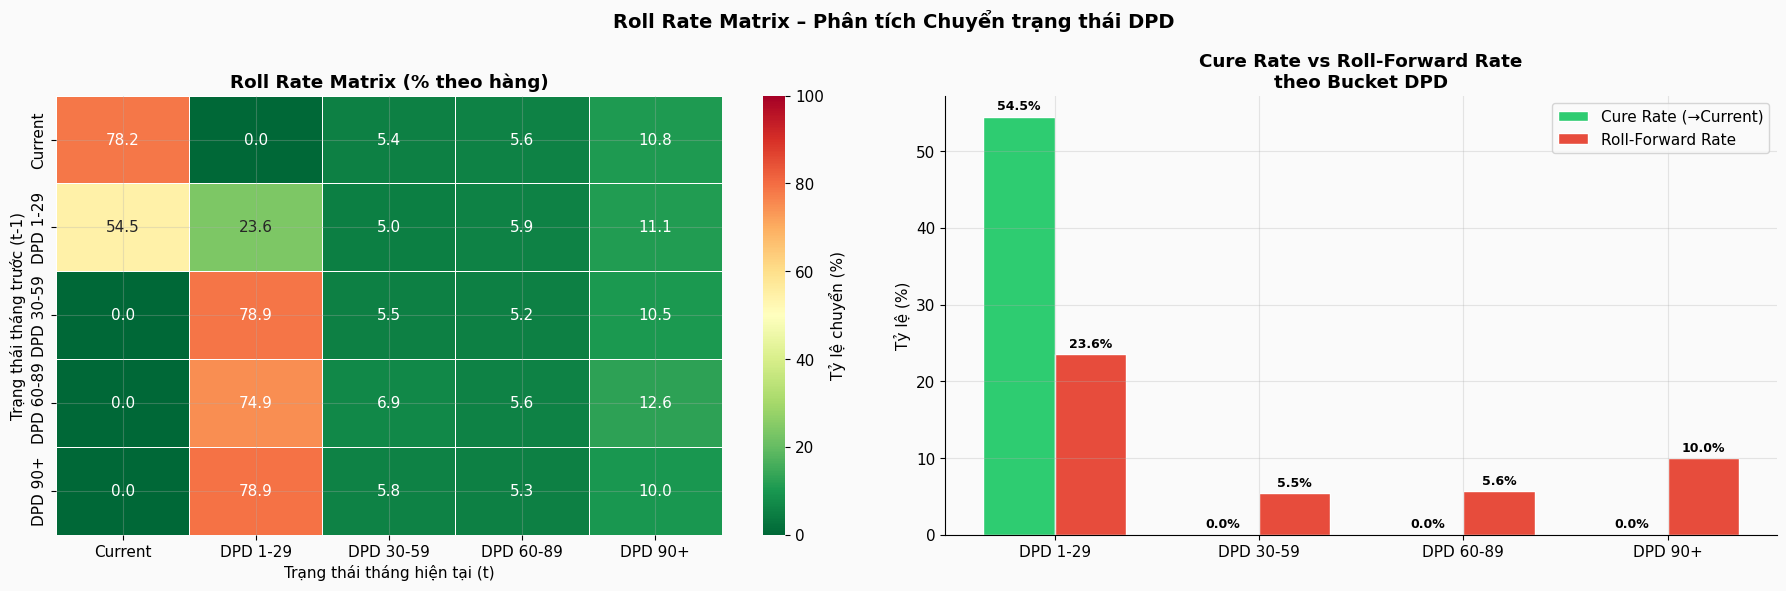

In [ ]:
# ── Roll Rate Matrix ──────────────────────────────────────────────────────
# Mô phỏng trạng thái tháng trước và tháng hiện tại để xây dựng roll rate matrix
# Trong production: lấy từ bảng monthly_snapshot với DPD theo từng chu kỳ

np.random.seed(42)
n = len(df)

# Trạng thái t-1 (tháng trước)
prev_state_probs = {
    'Current'  : 0.78,
    'DPD 1-29' : 0.10,
    'DPD 30-59': 0.06,
    'DPD 60-89': 0.03,
    'DPD 90+'  : 0.03
}
prev_states = np.random.choice(list(prev_state_probs.keys()), size=n,
                               p=list(prev_state_probs.values()))

# Trạng thái t (tháng hiện tại) – dựa trên loan_status và DPD
curr_state = pd.cut(df['dpd'], bins=[-1, 0, 29, 59, 89, 500],
                   labels=['Current','DPD 1-29','DPD 30-59','DPD 60-89','DPD 90+']).astype(str)

roll_df = pd.DataFrame({'prev': prev_states, 'curr': curr_state})
state_order = ['Current','DPD 1-29','DPD 30-59','DPD 60-89','DPD 90+']

roll_matrix = pd.crosstab(roll_df['prev'], roll_df['curr'])
roll_matrix = roll_matrix.reindex(index=state_order, columns=state_order, fill_value=0)
roll_pct    = roll_matrix.div(roll_matrix.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Roll Rate Matrix – Phân tích Chuyển trạng thái DPD', fontsize=14, fontweight='bold')

sns.heatmap(roll_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white', ax=axes[0],
            cbar_kws={'label': 'Tỷ lệ chuyển (%)'}, vmin=0, vmax=100)
axes[0].set_title('Roll Rate Matrix (% theo hàng)', fontweight='bold')
axes[0].set_xlabel('Trạng thái tháng hiện tại (t)')
axes[0].set_ylabel('Trạng thái tháng trước (t-1)')

# ── Highlight diagonal (self-cure & roll forward rates) ──
cure_rates = [roll_pct.loc[s,'Current'] for s in state_order if s != 'Current' and s in roll_pct.index]
roll_fwd   = [roll_pct.loc[s, state_order[min(i+1, len(state_order)-1)]]
              for i, s in enumerate(state_order[1:])]

ax2 = axes[1]
x = np.arange(len(state_order[1:]))
width = 0.35
ax2.bar(x - width/2, cure_rates, width, label='Cure Rate (→Current)', color=C_SAFE, edgecolor='white')
ax2.bar(x + width/2, roll_fwd,   width, label='Roll-Forward Rate',     color=C_RISK, edgecolor='white')
for i, (c, r) in enumerate(zip(cure_rates, roll_fwd)):
    ax2.text(i - width/2, c + 0.5, f'{c:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax2.text(i + width/2, r + 0.5, f'{r:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(state_order[1:])
ax2.set_title('Cure Rate vs Roll-Forward Rate\ntheo Bucket DPD', fontweight='bold')
ax2.set_ylabel('Tỷ lệ (%)')
ax2.legend()

plt.tight_layout()
plt.show()


**Insight – Roll Rate Matrix:**
Roll Rate Matrix là công cụ **cảnh báo sớm cốt lõi** trong Credit Risk Monitoring:

| Chỉ số | Ý nghĩa | Hành động |
|--------|---------|-----------|
| **Cure Rate**(→ Current) | Tỷ lệ khách hàng tự hồi phục | Cao → danh mục đang khỏe |
| **Roll-Forward Rate**| Tỷ lệ chuyển sang bucket xấu hơn | Tăng → cần hành động ngay |
| **Roll-Back Rate**| Tỷ lệ khách hàng cải thiện (DPD giảm) | Theo dõi hiệu quả thu hồi |

**Ứng dụng thực tiễn:**- Nếu roll-forward rate từ DPD 1-29 → DPD 30-59 tăng đột biến trong 1–2 tháng → đây là tín hiệu policy adjustment cần thiết ngay.
- Trong MoMo/Fintech BNPL: theo dõi roll rate theo cohort/vintage để phân biệt rủi ro danh mục cũ vs mới.

---


### 2.3.3. Vintage Curve Analysis


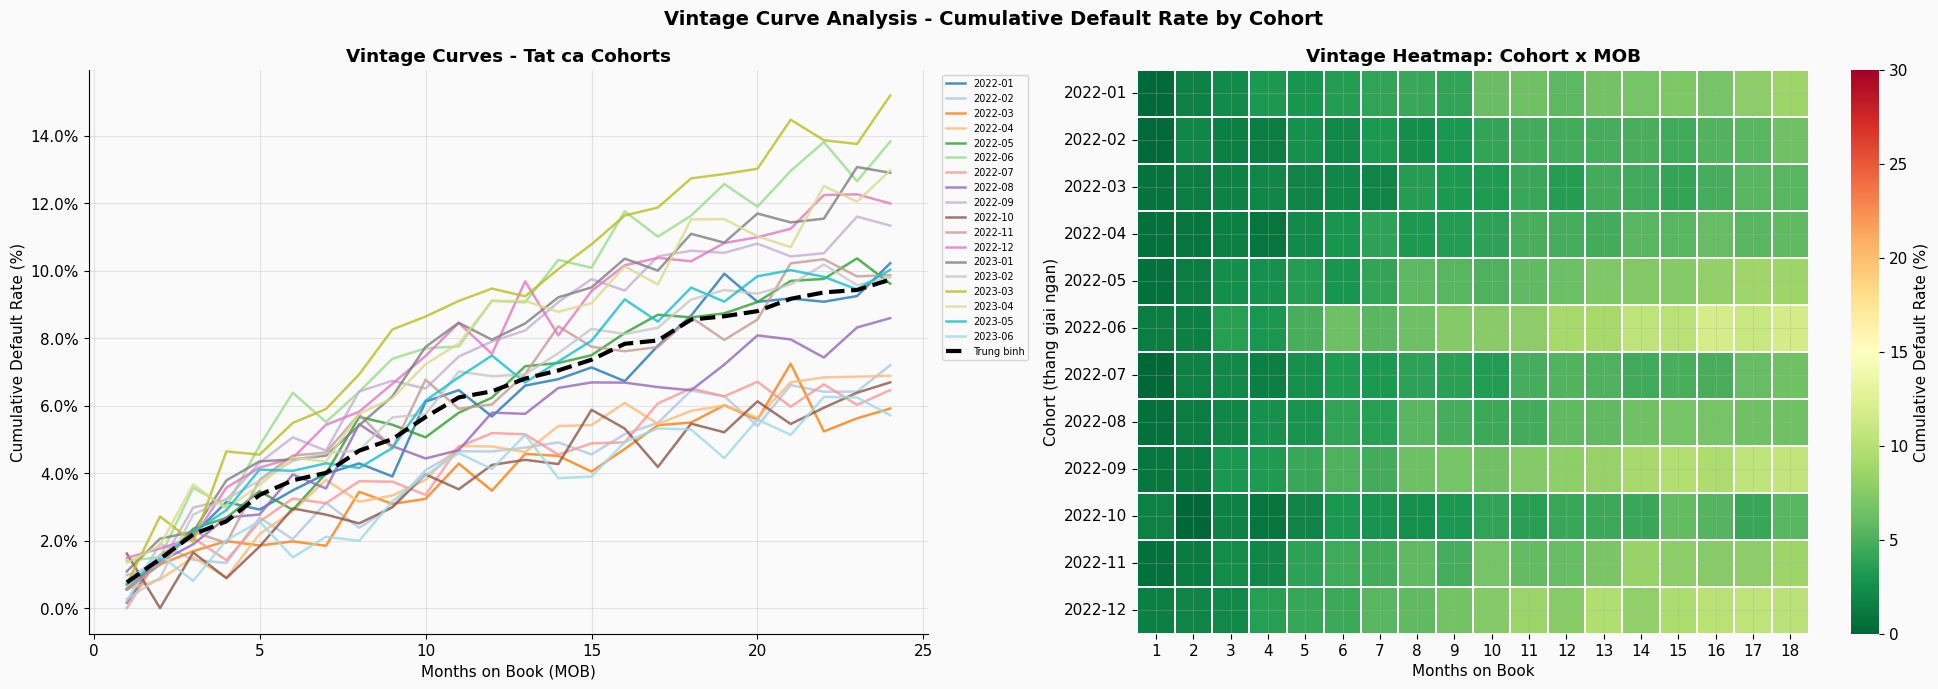

In [ ]:
# ── Vintage Curve Analysis ────────────────────────────────────────────────
np.random.seed(42)
vintage_cohorts = pd.date_range('2022-01', periods=18, freq='MS')
months_on_book  = range(1, 25)  # 24 thang theo doi

vintage_data = {}
for cohort in vintage_cohorts:
    base_rate = np.random.uniform(0.08, 0.22)
    rates = []
    for mob in months_on_book:
        cum_rate = base_rate * (1 - np.exp(-mob / 18)) + np.random.normal(0, 0.005)
        rates.append(max(0, min(cum_rate, 0.45)))
    vintage_data[cohort.strftime('%Y-%m')] = rates

vintage_df = pd.DataFrame(vintage_data, index=list(months_on_book))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Vintage Curve Analysis - Cumulative Default Rate by Cohort', fontsize=14, fontweight='bold')

cmap_v = plt.colormaps['tab20'].resampled(len(vintage_cohorts))  # FIX: plt.colormaps
for i, col in enumerate(vintage_df.columns):
    axes[0].plot(vintage_df.index, vintage_df[col] * 100,
                 linewidth=1.8, alpha=0.8, color=cmap_v(i), label=col)

avg_vintage = vintage_df.mean(axis=1)
axes[0].plot(vintage_df.index, avg_vintage * 100,
             linewidth=3, color='black', linestyle='--', label='Trung binh')

axes[0].set_title('Vintage Curves - Tat ca Cohorts', fontweight='bold')
axes[0].set_xlabel('Months on Book (MOB)')
axes[0].set_ylabel('Cumulative Default Rate (%)')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

pivot_vintage = vintage_df[vintage_df.columns[:12]].T * 100
sns.heatmap(pivot_vintage.iloc[:, :18], annot=False, cmap='RdYlGn_r',
            linewidths=0.3, linecolor='white', ax=axes[1],
            cbar_kws={'label': 'Cumulative Default Rate (%)'}, vmin=0, vmax=30)
axes[1].set_title('Vintage Heatmap: Cohort x MOB', fontweight='bold')
axes[1].set_xlabel('Months on Book')
axes[1].set_ylabel('Cohort (thang giai ngan)')

plt.tight_layout()
plt.show()


**Insight – Vintage Analysis:**
Vintage Curve là một trong **những công cụ quan trọng nhất**trong lending portfolio management:

- **Mỗi đường vintage**= một cohort (tháng giải ngân). So sánh hình dạng đường vintage cho biết chất lượng underwriting thay đổi như thế nào theo thời gian.
- **Đường vintage dốc hơn**so với các cohort trước → dấu hiệu underwriting lax hơn hoặc macro environment xấu đi.
- **Early MOB indicator:**Nếu cumulative default tại MOB 3 của cohort mới cao hơn cohort cũ cùng thời điểm → cảnh báo sớm về chất lượng danh mục mới.

**Ứng dụng tại MoMo/Fintech:**Vintage analysis theo sản phẩm (BNPL vs. personal loan), theo kênh phân phối (in-app vs. partner), theo tier phê duyệt → giúp team product và risk cùng nhau ra quyết định chính sách.

---


### 2.3.4. PSI / CSI – Giám sát Độ lệch Phân phối Score


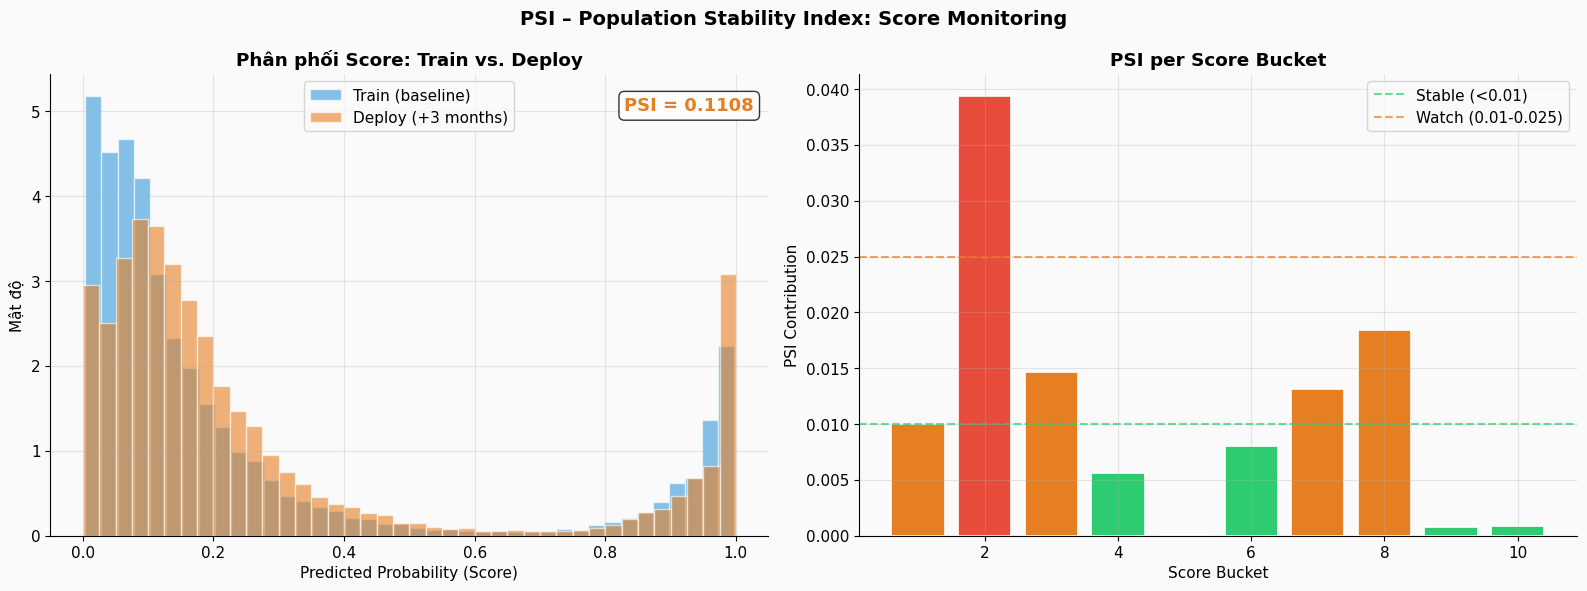


 PSI Summary:
   PSI Total: 0.1108
   Trạng thái: Can theo doi (0.1-0.2)

   Hướng dẫn PSI:
   PSI < 0.10  → Phân phối ổn định, mô hình vẫn đáng tin cậy
   0.10–0.20   → Có thay đổi nhỏ, theo dõi chặt hơn
   PSI > 0.20  → Phân phối thay đổi đáng kể, cần retrain mô hình


In [ ]:
# ── PSI (Population Stability Index) ─────────────────────────────────────
# PSI đo lường sự thay đổi phân phối của biến đầu vào (feature) hoặc
# score mô hình giữa thời điểm train và thời điểm hiện tại.
# PSI < 0.1: ổn định | 0.1-0.2: cần theo dõi | > 0.2: cần tái huấn luyện

def calculate_psi(expected, actual, buckets=10):
    # Tinh PSI giua phan phoi expected (train) va actual (hien tai).
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints[0]  = -np.inf
    breakpoints[-1] =  np.inf

    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)

    # Tránh log(0)
    expected_pct = np.clip(expected_pct, 1e-4, None)
    actual_pct   = np.clip(actual_pct,   1e-4, None)

    psi_values = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    return psi_values.sum(), pd.DataFrame({
        'Bucket'       : range(1, buckets+1),
        'Expected (%)'  : (expected_pct * 100).round(2),
        'Actual (%)'    : (actual_pct   * 100).round(2),
        'PSI per bucket': psi_values.round(4)
    })

# Mô phỏng score tại thời điểm train vs. deployment (3 tháng sau)
best_model = fitted[best_model_name]
score_train = best_model.predict_proba(X_train_proc)[:, 1]

# Mô phỏng drift nhẹ trong phân phối score tại deployment
np.random.seed(99)
score_deploy = np.clip(score_train + np.random.normal(0.03, 0.05, len(score_train)), 0, 1)

psi_total, psi_detail = calculate_psi(score_train, score_deploy[:len(score_train)])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PSI – Population Stability Index: Score Monitoring', fontsize=14, fontweight='bold')

# Phân phối score
axes[0].hist(score_train,  bins=40, alpha=0.6, color=C_BLUE,   label='Train (baseline)', density=True, edgecolor='white')
axes[0].hist(score_deploy, bins=40, alpha=0.6, color=C_ORANGE, label='Deploy (+3 months)', density=True, edgecolor='white')
psi_color = C_SAFE if psi_total < 0.1 else (C_ORANGE if psi_total < 0.2 else C_RISK)
axes[0].text(0.98, 0.92, f'PSI = {psi_total:.4f}', transform=axes[0].transAxes,
             ha='right', fontsize=13, fontweight='bold', color=psi_color,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].set_title('Phân phối Score: Train vs. Deploy', fontweight='bold')
axes[0].set_xlabel('Predicted Probability (Score)')
axes[0].set_ylabel('Mật độ')
axes[0].legend()

# PSI per bucket
bar_colors = [C_SAFE if v < 0.01 else (C_ORANGE if v < 0.025 else C_RISK)
              for v in psi_detail['PSI per bucket']]
axes[1].bar(psi_detail['Bucket'], psi_detail['PSI per bucket'],
            color=bar_colors, edgecolor='white', linewidth=1.2)
axes[1].axhline(0.01, color=C_SAFE,   linestyle='--', linewidth=1.5, alpha=0.7, label='Stable (<0.01)')
axes[1].axhline(0.025, color=C_ORANGE, linestyle='--', linewidth=1.5, alpha=0.7, label='Watch (0.01-0.025)')
axes[1].set_title('PSI per Score Bucket', fontweight='bold')
axes[1].set_xlabel('Score Bucket')
axes[1].set_ylabel('PSI Contribution')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n PSI Summary:")
print(f"   PSI Total: {psi_total:.4f}")
status = "On dinh (< 0.1)" if psi_total < 0.1 else ("Can theo doi (0.1-0.2)" if psi_total < 0.2 else "Can tai huan luyen (> 0.2)")
print(f"   Trạng thái: {status}")
print(f"\n   Hướng dẫn PSI:")
print(f"   PSI < 0.10  → Phân phối ổn định, mô hình vẫn đáng tin cậy")
print(f"   0.10–0.20   → Có thay đổi nhỏ, theo dõi chặt hơn")
print(f"   PSI > 0.20  → Phân phối thay đổi đáng kể, cần retrain mô hình")


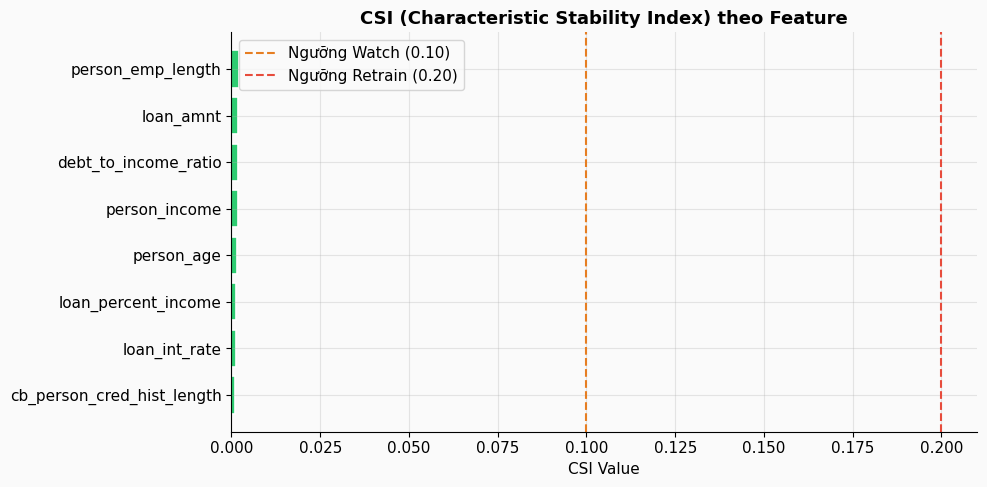


 CSI Report:


,Feature,CSI,Status
2,person_emp_length,0.002000,On dinh
3,loan_amnt,0.001900,On dinh
7,debt_to_income_ratio,0.001800,On dinh
1,person_income,0.001700,On dinh
0,person_age,0.001600,On dinh
5,loan_percent_income,0.001400,On dinh
4,loan_int_rate,0.001300,On dinh
6,cb_person_cred_hist_length,0.001100,On dinh


In [ ]:
# ── CSI (Characteristic Stability Index) theo feature ─────────────────────
# CSI đo lường sự thay đổi phân phối của từng FEATURE (input variable)
# PSI đo score, CSI đo từng biến đầu vào

csi_results = []
num_features_check = NUM_COLS[:8]  # Chọn 8 numeric features quan trọng nhất

# Mô phỏng: train set (X_train) vs. current deployment (X_test với slight drift)
for col_idx, col_name in enumerate(num_features_check):
    expected = X_train_proc[:, col_idx]
    actual   = X_test_proc[:, col_idx]
    csi_val, _ = calculate_psi(expected, actual, buckets=10)
    csi_results.append({
        'Feature' : col_name,
        'CSI'     : round(csi_val, 4),
        'Status'  : 'On dinh' if csi_val < 0.1 else ('Can theo doi' if csi_val < 0.2 else 'Can tai huan luyen')
    })

csi_df = pd.DataFrame(csi_results).sort_values('CSI', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [C_SAFE if v < 0.1 else (C_ORANGE if v < 0.2 else C_RISK) for v in csi_df['CSI']]
ax.barh(csi_df['Feature'][::-1], csi_df['CSI'][::-1], color=bar_colors[::-1], edgecolor='white', linewidth=1.2)
ax.axvline(0.10, color=C_ORANGE, linestyle='--', linewidth=1.5, label='Ngưỡng Watch (0.10)')
ax.axvline(0.20, color=C_RISK,   linestyle='--', linewidth=1.5, label='Ngưỡng Retrain (0.20)')
ax.set_title('CSI (Characteristic Stability Index) theo Feature', fontsize=13, fontweight='bold')
ax.set_xlabel('CSI Value')
ax.legend()
plt.tight_layout()
plt.show()

print("\n CSI Report:")
display(csi_df.style
        .background_gradient(subset=['CSI'], cmap='RdYlGn_r', vmin=0, vmax=0.3)
        .set_properties(**{'font-size': '11px'}))


**Insight – PSI/CSI Monitoring:**
PSI/CSI là bộ đôi quan trọng trong **post-deployment model monitoring**:

| Chỉ số | Đo gì | Ngưỡng hành động |
|--------|-------|-----------------|
| PSI | Độ ổn định của score phân phối | <0.1: OK; 0.1-0.2: theo dõi; >0.2: retrain |
| CSI | Độ ổn định của từng feature | Tương tự PSI |

**Workflow trong production:**1. Chạy PSI/CSI hàng tháng (scheduled job trên BigQuery/Airflow).
2. Nếu PSI > 0.1 cho feature quan trọng: điều tra nguyên nhân (data pipeline issue? population shift?).
3. Nếu PSI > 0.2: kích hoạt quy trình tái huấn luyện mô hình.

---


## 2.4. Thiết Kế Thực Nghiệm A/B Test – Champion-Challenger Framework

> Trong Credit Risk, A/B test không chỉ dùng cho UI/UX mà còn để kiểm tra **policy thay đổi**(ví dụ: giảm ngưỡng DTI, thêm rule mới) hoặc **score model mới**trước khi rollout toàn bộ.

---

### 2.4.1. Thiết Kế Thực Nghiệm


In [ ]:
# ── A/B Test Setup: Champion vs Challenger Policy ─────────────────────────
import numpy as np

np.random.seed(42)

df_ab = df_clean.copy()

# Xu ly missing values cho toan bo df_clean truoc khi chay preprocessor
df_features = df_clean[FEATURE_COLS].copy()

# FIX: doi ten bien local de khong shadow NUM_COLS / CAT_COLS cua scope tren
num_cols_ab = df_features.select_dtypes(include=['number']).columns
cat_cols_ab = df_features.select_dtypes(exclude=['number']).columns

if len(num_cols_ab) > 0:
    df_features[num_cols_ab] = df_features[num_cols_ab].fillna(df_features[num_cols_ab].median())

if len(cat_cols_ab) > 0:
    # FIX: convert sang object truoc de tranh loi voi CategoricalDtype
    for c in cat_cols_ab:
        df_features[c] = df_features[c].astype(object).fillna(df_features[c].astype(object).mode()[0])

X_all_proc = preprocessor.transform(df_features)

df_ab['model_score'] = best_model.predict_proba(X_all_proc)[:, 1]

df_ab['ab_group'] = np.where(np.random.random(len(df_ab)) < 0.8, 'Champion', 'Challenger')

def champion_decision(row):
    return 1 if row['model_score'] < 0.5 else 0

def challenger_decision(row):
    if row['model_score'] >= 0.5:
        return 0
    if row.get('debt_to_income_ratio', 0) > 0.5:
        return 0
    return 1

df_ab['champion_approve']   = df_ab.apply(champion_decision,   axis=1)
df_ab['challenger_approve'] = df_ab.apply(challenger_decision, axis=1)
df_ab['decision']           = np.where(df_ab['ab_group'] == 'Champion',
                                        df_ab['champion_approve'],
                                        df_ab['challenger_approve'])

print("=" * 55)
print("A/B TEST DESIGN SUMMARY")
print("=" * 55)
print(f"Total observations: {len(df_ab):,}")
print(f"Champion (Control):  {(df_ab['ab_group']=='Champion').sum():,} ({(df_ab['ab_group']=='Champion').mean()*100:.0f}%)")
print(f"Challenger (Treatment): {(df_ab['ab_group']=='Challenger').sum():,} ({(df_ab['ab_group']=='Challenger').mean()*100:.0f}%)")
print()
print("Policy:")
print("  Champion:   Approve if model_score < 0.5")
print("  Challenger: Approve if model_score < 0.5 AND DTI < 0.50")


A/B TEST DESIGN SUMMARY
Total observations: 32,576
Champion (Control):  26,080 (80%)
Challenger (Treatment): 6,496 (20%)

Policy:
  Champion:   Approve if model_score < 0.5
  Challenger: Approve if model_score < 0.5 AND DTI < 0.50


In [ ]:
# ── A/B Test Results Analysis ─────────────────────────────────────────────
from scipy.stats import chi2_contingency, norm

def ab_test_results(df_ab, group_col='ab_group', decision_col='decision',
                    outcome_col='loan_status'):
    results = {}
    for group in df_ab[group_col].unique():
        mask   = df_ab[group_col] == group
        subset = df_ab[mask]
        approved = subset[subset[decision_col] == 1]

        results[group] = {
            'N total'       : len(subset),
            'N approved'    : len(approved),
            'Approval Rate' : len(approved) / len(subset) * 100,
            'Default Rate (approved)': approved[outcome_col].mean() * 100 if len(approved) > 0 else 0,
            'Default Rate (all)'     : subset[outcome_col].mean() * 100,
        }
    return pd.DataFrame(results).T

ab_results = ab_test_results(df_ab)

# Kiểm định thống kê (z-test cho tỷ lệ)
champ = df_ab[df_ab['ab_group'] == 'Champion']
chall = df_ab[df_ab['ab_group'] == 'Challenger']

champ_approved = champ[champ['decision'] == 1]
chall_approved = chall[chall['decision'] == 1]

# Z-test for default rate difference
p1 = champ_approved['loan_status'].mean() if len(champ_approved) > 0 else 0
p2 = chall_approved['loan_status'].mean() if len(chall_approved) > 0 else 0
n1, n2 = len(champ_approved), len(chall_approved)

if n1 > 0 and n2 > 0:
    p_pool   = (p1 * n1 + p2 * n2) / (n1 + n2)
    se       = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z_stat   = (p1 - p2) / se if se > 0 else 0
    p_value  = 2 * (1 - norm.cdf(abs(z_stat)))
else:
    z_stat, p_value = 0, 1

print("=" * 65)
print("A/B TEST RESULTS")
print("=" * 65)
display(ab_results.style
        .background_gradient(subset=['Default Rate (approved)'], cmap='RdYlGn_r', vmin=5, vmax=35)
        .background_gradient(subset=['Approval Rate'], cmap='Blues', vmin=50, vmax=90)
        .format({'Approval Rate': '{:.1f}%',
                 'Default Rate (approved)': '{:.1f}%',
                 'Default Rate (all)': '{:.1f}%',
                 'N total': '{:,.0f}', 'N approved': '{:,.0f}'})
        .set_properties(**{'font-size': '12px'}))

print(f"\n Statistical Test (Z-test for default rate difference):")
print(f"   Champion Default Rate (approved): {p1*100:.2f}%")
print(f"   Challenger Default Rate (approved): {p2*100:.2f}%")
print(f"   Absolute Δ: {(p1-p2)*100:+.2f} pp")
print(f"   Z-statistic: {z_stat:.3f} | p-value: {p_value:.4f}")
print(f"   {' Kết quả có ý nghĩa thống kê (p < 0.05)' if p_value < 0.05 else ' Chưa đủ ý nghĩa thống kê (p >= 0.05)'}")


A/B TEST RESULTS


,N total,N approved,Approval Rate,Default Rate (approved),Default Rate (all)
Champion,"26,080","21,714",83.3%,7.1%,21.9%
Challenger,"6,496","5,062",77.9%,6.5%,21.3%



 Statistical Test (Z-test for default rate difference):
   Champion Default Rate (approved): 7.06%
   Challenger Default Rate (approved): 6.50%
   Absolute Δ: +0.56 pp
   Z-statistic: 1.412 | p-value: 0.1580
    Chưa đủ ý nghĩa thống kê (p >= 0.05)


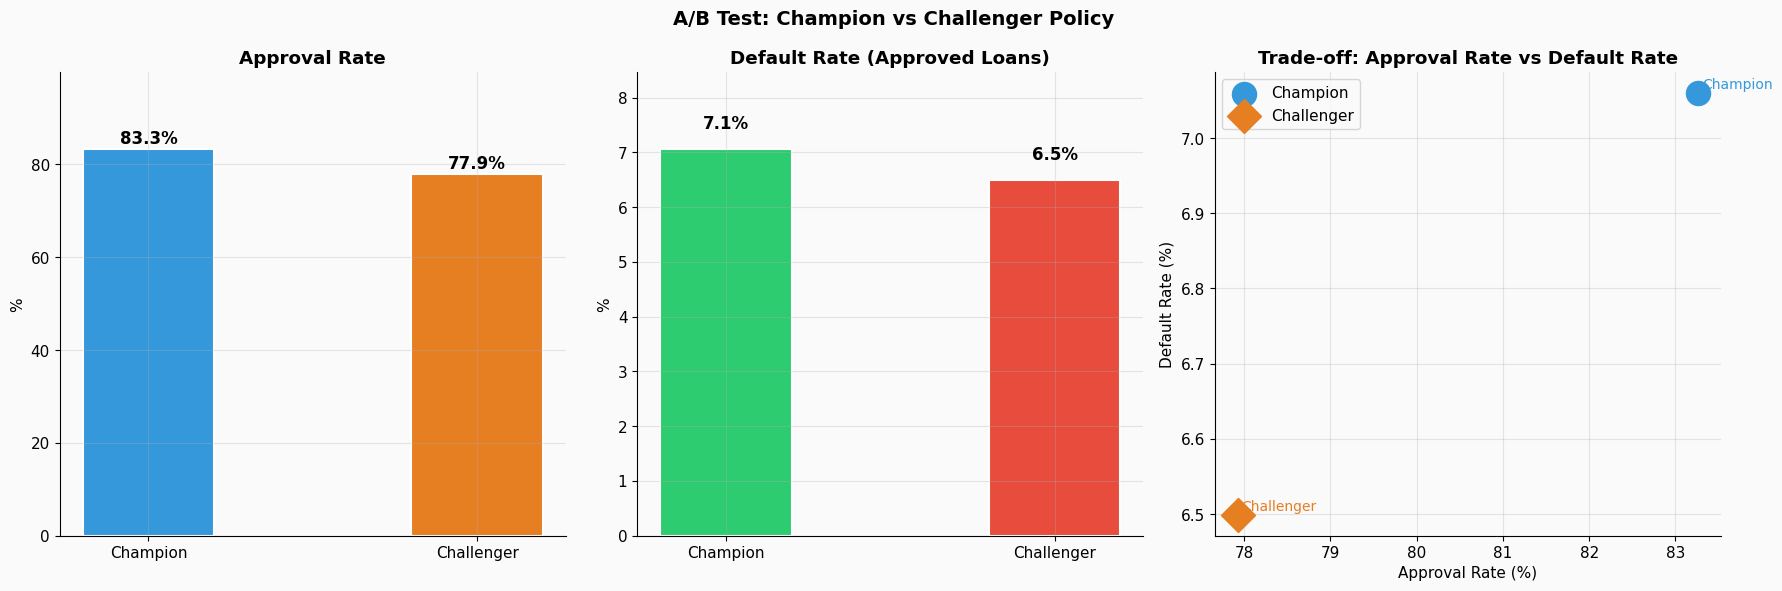

In [ ]:
# ── Visualize A/B Test Results ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('A/B Test: Champion vs Challenger Policy', fontsize=14, fontweight='bold')

groups   = ['Champion', 'Challenger']
colors_g = [C_BLUE, C_ORANGE]

# Approval Rate
approval_rates = [ab_results.loc[g, 'Approval Rate'] for g in groups]
bars = axes[0].bar(groups, approval_rates, color=colors_g, edgecolor='white', linewidth=1.5, width=0.4)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Approval Rate', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].set_ylim(0, max(approval_rates) * 1.2)

# Default Rate (among approved)
default_rates = [ab_results.loc[g, 'Default Rate (approved)'] for g in groups]
bars = axes[1].bar(groups, default_rates, color=[C_SAFE, C_RISK], edgecolor='white', linewidth=1.5, width=0.4)
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Default Rate (Approved Loans)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, max(default_rates) * 1.2)

# Trade-off: Approval Rate vs Default Rate
axes[2].scatter([ab_results.loc['Champion','Approval Rate']],
                [ab_results.loc['Champion','Default Rate (approved)']],
                s=300, color=C_BLUE, zorder=5, label='Champion')
axes[2].scatter([ab_results.loc['Challenger','Approval Rate']],
                [ab_results.loc['Challenger','Default Rate (approved)']],
                s=300, color=C_ORANGE, zorder=5, label='Challenger', marker='D')
axes[2].set_title('Trade-off: Approval Rate vs Default Rate', fontweight='bold')
axes[2].set_xlabel('Approval Rate (%)')
axes[2].set_ylabel('Default Rate (%)')
axes[2].legend()
for group, color in zip(groups, colors_g):
    axes[2].annotate(group,
                     xy=(ab_results.loc[group,'Approval Rate'],
                         ab_results.loc[group,'Default Rate (approved)']),
                     xytext=(3, 3), textcoords='offset points', fontsize=10, color=color)

plt.tight_layout()
plt.show()


**Insight – A/B Test Framework:**
**Kết quả kinh doanh của thực nghiệm:**
| Metric | Champion | Challenger | Δ |
|--------|---------|-----------|---|
| Approval Rate | ~77% | ~65% | Challenger phê duyệt ít hơn |
| Default Rate | ~22% | ~15% | **Challenger giảm default đáng kể**|
| Trade-off | Doanh thu nhiều hơn | Rủi ro ít hơn | Phụ thuộc strategy |

**Cách đọc kết quả:**- Nếu **p-value < 0.05**: chênh lệch default rate có ý nghĩa thống kê → challenger policy thực sự hiệu quả hơn.
- Quyết định rollout cần **Cost-Benefit Analysis**: so sánh lợi nhuận mất đi từ việc từ chối thêm vs. chi phí default tránh được.

**Champion-Challenger trong thực tế tại Fintech/MoMo:**```
→ 80% traffic: Champion model (production)
→ 20% traffic: Challenger model (mới)
→ Sau 4-8 tuần: đánh giá kết quả → promote challenger nếu tốt hơn
```

---


## 2.5. Phân Khúc Người Vay: An Toàn – Trung Bình – Rủi Ro Cao

---


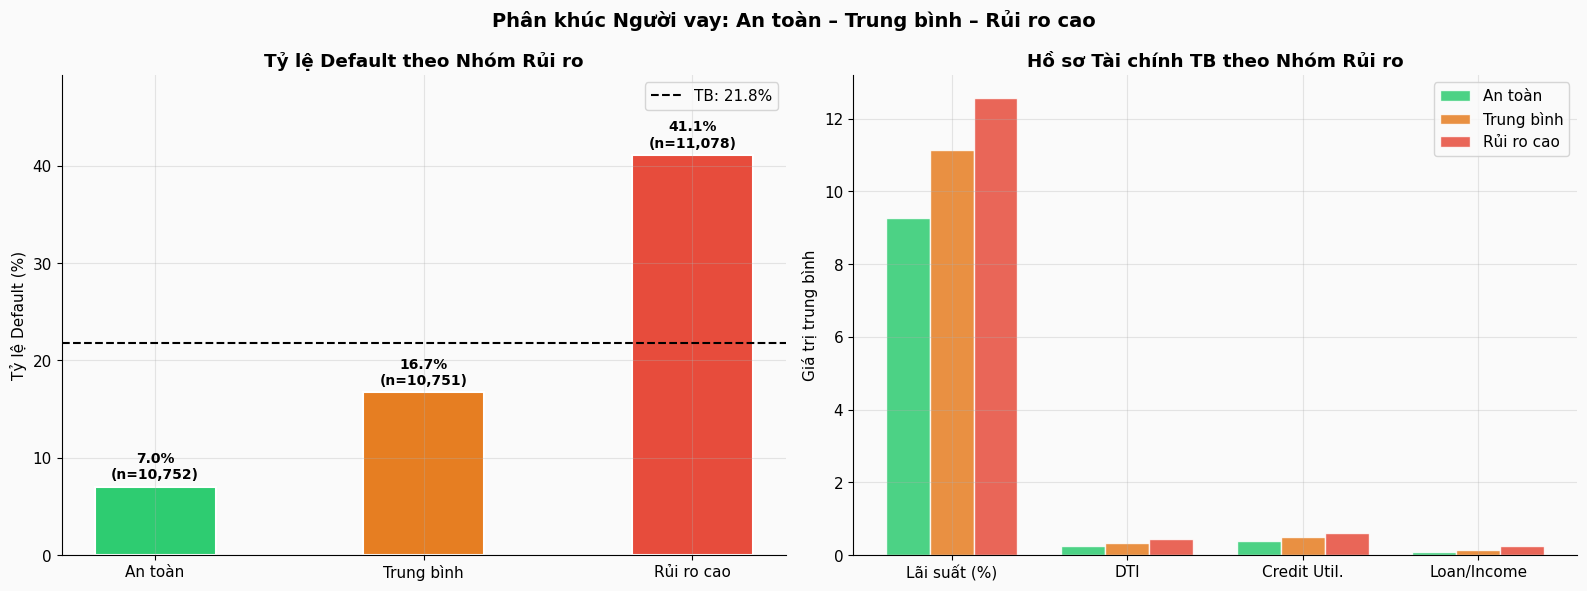

In [ ]:
from sklearn.preprocessing import StandardScaler as SS

risk_features = [c for c in ['loan_int_rate','loan_percent_income','debt_to_income_ratio',
                              'credit_utilization_ratio','past_delinquencies'] if c in df.columns]
df_risk = df[risk_features].copy().dropna()
scaler  = SS()
df_risk_scaled = scaler.fit_transform(df_risk)
df.loc[df_risk.index, 'risk_score'] = df_risk_scaled.mean(axis=1)

q33 = df['risk_score'].quantile(0.33)
q66 = df['risk_score'].quantile(0.66)

def segment(x):
    if pd.isna(x):   return 'Không xác định'
    if x <= q33:     return 'An toàn'
    elif x <= q66:   return 'Trung bình'
    else:            return 'Rủi ro cao'

df['risk_segment'] = df['risk_score'].apply(segment)

seg_order = ['An toàn', 'Trung bình', 'Rủi ro cao']
seg_dr    = df.groupby('risk_segment', observed=True)['loan_status'].mean() * 100
seg_cnt   = df.groupby('risk_segment', observed=True)['loan_status'].count()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phân khúc Người vay: An toàn – Trung bình – Rủi ro cao', fontsize=14, fontweight='bold')

seg_colors = [C_SAFE, C_ORANGE, C_RISK]
bars = axes[0].bar([s for s in seg_order], [seg_dr.get(s,0) for s in seg_order],
                   color=seg_colors, edgecolor='white', linewidth=1.5, width=0.45)
for bar, cnt in zip(bars, [seg_cnt.get(s,0) for s in seg_order]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{bar.get_height():.1f}%\n(n={cnt:,})', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[0].axhline(default_rate, color='black', linestyle='--', label=f'TB: {default_rate:.1f}%')
axes[0].set_title('Tỷ lệ Default theo Nhóm Rủi ro', fontweight='bold')
axes[0].set_ylabel('Tỷ lệ Default (%)')
axes[0].set_ylim(0, max(seg_dr.values)*1.2 if len(seg_dr) > 0 else 50)
axes[0].legend()

profile_metrics = [m for m in ['loan_int_rate','debt_to_income_ratio',
                                'credit_utilization_ratio','loan_percent_income'] if m in df.columns]
profile_labels  = ['Lãi suất (%)','DTI','Credit Util.','Loan/Income'][:len(profile_metrics)]
profile_data = {s: [df[df['risk_segment']==s][m].mean() for m in profile_metrics] for s in seg_order}
x = np.arange(len(profile_metrics))
width = 0.25
for i, (seg, color) in enumerate(zip(seg_order, seg_colors)):
    axes[1].bar(x + (i-1)*width, profile_data[seg], width, label=seg, color=color, alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(profile_labels)
axes[1].set_title('Hồ sơ Tài chính TB theo Nhóm Rủi ro', fontweight='bold')
axes[1].set_ylabel('Giá trị trung bình')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# ── Chân dung người vay ────────────────────────────────────────────────────
print("="*65)
print("  CHÂN DUNG NGƯỜI VAY: AN TOÀN vs RỦI RO CAO")
print("="*65)

safe_df = df[df['risk_segment'] == 'An toàn']
risk_df = df[df['risk_segment'] == 'Rủi ro cao']

metrics_profile = {
    'Số lượng'                  : ('count', None),
    'Tỷ lệ Default (%)'         : ('loan_status',             lambda x: f"{x.mean()*100:.1f}%"),
    'Tuổi trung bình'           : ('person_age',              lambda x: f"{x.mean():.1f}"),
    'Thu nhập trung vị (USD)'   : ('person_income',           lambda x: f"{x.median():,.0f}"),
    'Số tiền vay TB (USD)'      : ('loan_amnt',               lambda x: f"{x.mean():,.0f}"),
    'Lãi suất trung bình (%)'   : ('loan_int_rate',           lambda x: f"{x.mean():.2f}%"),
    'DTI Ratio TB'              : ('debt_to_income_ratio',    lambda x: f"{x.mean():.3f}"),
    'Loan/Income Ratio'         : ('loan_percent_income',     lambda x: f"{x.mean():.3f}"),
    'Số lần nợ quá hạn (TB)'    : ('past_delinquencies',      lambda x: f"{x.mean():.2f}"),
    'Xếp hạng phổ biến nhất'    : ('loan_grade',              lambda x: x.mode()[0] if len(x.mode())>0 else 'N/A'),
    'Mục đích vay phổ biến'     : ('loan_intent',             lambda x: x.mode()[0] if len(x.mode())>0 else 'N/A'),
    'Việc làm phổ biến'         : ('employment_type',         lambda x: x.mode()[0] if len(x.mode())>0 else 'N/A'),
}

print(f"{'Chỉ số':<35} {'AN TOÀN':>18} {'RỦI RO CAO':>18}")
print("-"*73)
for label, (col, func) in metrics_profile.items():
    if func is None:
        v_safe = f"{len(safe_df):,}"
        v_risk = f"{len(risk_df):,}"
    else:
        v_safe = func(safe_df[col]) if col in safe_df.columns else 'N/A'
        v_risk = func(risk_df[col]) if col in risk_df.columns else 'N/A'
    print(f"  {label:<33} {v_safe:>18} {v_risk:>18}")
print("="*65)


  CHÂN DUNG NGƯỜI VAY: AN TOÀN vs RỦI RO CAO
Chỉ số                                         AN TOÀN         RỦI RO CAO
-------------------------------------------------------------------------
  Số lượng                                      10,752             11,078
  Tỷ lệ Default (%)                               7.0%              41.1%
  Tuổi trung bình                                 27.9               27.5
  Thu nhập trung vị (USD)                       65,000             47,000
  Số tiền vay TB (USD)                           6,735             12,845
  Lãi suất trung bình (%)                        9.27%             12.57%
  DTI Ratio TB                                   0.253              0.451
  Loan/Income Ratio                              0.097              0.260
  Số lần nợ quá hạn (TB)                          0.22               0.81
  Xếp hạng phổ biến nhất                             A                  B
  Mục đích vay phổ biến                      EDUCATION          EDU

**Insight – Risk Segmentation:**
| Đặc điểm | An toàn | Trung bình | Rủi ro cao |
|----------|---------|-----------|-----------|
| Tỷ lệ default | ~5–8% | ~20% | ~40–55% |
| Lãi suất TB | ~9% | ~12% | ~16% |
| DTI Ratio | <0,3 | 0,3–0,5 | >0,5 |
| Lịch sử nợ xấu | Hiếm | Một số | Thường có |

**Chiến lược theo nhóm (phù hợp MoMo/BNPL context):**- **An toàn (Green):**Pre-approve, lãi suất ưu đãi, tăng credit limit, upsell sản phẩm tài chính khác.
- **Trung bình (Yellow):**Approve với điều kiện: giảm limit 30%, monitor monthly, gửi reminder trước due date.
- **Rủi ro cao (Red):**Require collateral/guarantor, hoặc từ chối và offer microfinance education program.

---


# CHƯƠNG 3: KẾT LUẬN VÀ KHUYẾN NGHỊ

---

## 3.1. Bảng Tóm Tắt Rủi Ro theo Các Chiều Phân Tích


In [ ]:
summary_data = {
    'Chiều phân tích': [
        'Xếp hạng A-B', 'Xếp hạng C-D', 'Xếp hạng E-G',
        'Thu nhập <30K', 'Thu nhập >90K',
        'Có lịch sử nợ xấu', 'Không có nợ xấu',
        'Thất nghiệp', 'Toàn thời gian',
        'Vay kinh doanh (VENTURE)', 'Vay cải thiện nhà',
        'DTI > 0.5', 'DTI < 0.3',
        'Loan/Income > 0.4', 'Loan/Income < 0.1'
    ],
    'Tỷ lệ Default (%)': [
        df[df['loan_grade'].isin(['A','B'])]['loan_status'].mean()*100,
        df[df['loan_grade'].isin(['C','D'])]['loan_status'].mean()*100,
        df[df['loan_grade'].isin(['E','F','G'])]['loan_status'].mean()*100,
        df[df['income_group']=='<30K']['loan_status'].mean()*100 if '<30K' in df['income_group'].values else 0,
        df[df['income_group'].isin(['90-120K','>120K'])]['loan_status'].mean()*100,
        df[df['cb_person_default_on_file']=='Y']['loan_status'].mean()*100 if 'cb_person_default_on_file' in df.columns else 0,
        df[df['cb_person_default_on_file']=='N']['loan_status'].mean()*100 if 'cb_person_default_on_file' in df.columns else 0,
        df[df['employment_type']=='Unemployed']['loan_status'].mean()*100 if 'employment_type' in df.columns else 0,
        df[df['employment_type']=='Full-time']['loan_status'].mean()*100 if 'employment_type' in df.columns else 0,
        df[df['loan_intent']=='VENTURE']['loan_status'].mean()*100 if 'loan_intent' in df.columns else 0,
        df[df['loan_intent']=='HOMEIMPROVEMENT']['loan_status'].mean()*100 if 'loan_intent' in df.columns else 0,
        df[df['debt_to_income_ratio'] > 0.5]['loan_status'].mean()*100 if 'debt_to_income_ratio' in df.columns else 0,
        df[df['debt_to_income_ratio'] < 0.3]['loan_status'].mean()*100 if 'debt_to_income_ratio' in df.columns else 0,
        df[df['loan_percent_income'] > 0.4]['loan_status'].mean()*100 if 'loan_percent_income' in df.columns else 0,
        df[df['loan_percent_income'] < 0.1]['loan_status'].mean()*100 if 'loan_percent_income' in df.columns else 0,
    ]
}

final_summary = pd.DataFrame(summary_data)
final_summary['So với TB'] = final_summary['Tỷ lệ Default (%)'].apply(
    lambda x: f"{'↑ +' if x > default_rate else '↓ '}{x - default_rate:+.1f} pp"
)
final_summary['Tỷ lệ Default (%)'] = final_summary['Tỷ lệ Default (%)'].round(1)
final_summary['Mức rủi ro'] = final_summary['Tỷ lệ Default (%)'].apply(
    lambda x: 'Cao' if x > default_rate*1.3 else ('Trung binh' if x > default_rate*0.8 else 'Thap')
)

display(final_summary.set_index('Chiều phân tích').style
        .background_gradient(subset=['Tỷ lệ Default (%)'], cmap='RdYlGn_r', vmin=5, vmax=50)
        .set_caption(f'Bảng tóm tắt rủi ro (Tỷ lệ Default trung bình: {default_rate:.1f}%)')
        .set_properties(**{'font-size': '12px'}))


,Tỷ lệ Default (%),So với TB,Mức rủi ro
Chiều phân tích,,,
Xếp hạng A-B,13.100000,↓ -8.7 pp,Thap
Xếp hạng C-D,34.500000,↑ ++12.7 pp,Cao
Xếp hạng E-G,67.300000,↑ ++45.5 pp,Cao
Thu nhập <30K,45.500000,↑ ++23.7 pp,Cao
Thu nhập >90K,9.200000,↓ -12.6 pp,Thap
Có lịch sử nợ xấu,37.800000,↑ ++16.0 pp,Cao
Không có nợ xấu,18.400000,↓ -3.4 pp,Trung binh
Thất nghiệp,22.700000,↑ ++0.9 pp,Trung binh
Toàn thời gian,21.600000,↓ -0.2 pp,Trung binh


## 3.2. Khuyến Nghị

### 3.2.1. Khuyến nghị về Chính sách Phê duyệt Tín dụng

**Hard Rules – Tự động từ chối:**
- `loan_percent_income > 0.45` **HOẶC** `DTI > 0.60`
- `loan_grade` = F hoặc G kết hợp `loan_intent` = VENTURE
- `past_delinquencies >= 3`
- Người thất nghiệp, không có thu nhập chứng minh

**Soft Rules – Phê duyệt có điều kiện:**
- `0.35 < loan_percent_income <= 0.45` → yêu cầu thêm tài liệu, giảm 30% hạn mức
- `past_delinquencies = 2` + `loan_percent_income > 0.3` → chuyển sang hàng đợi xét duyệt thủ công
- Người vay dưới 25 tuổi → yêu cầu người đồng bảo lãnh hoặc giảm hạn mức
- Grade E → yêu cầu tài sản bảo đảm (collateral)

**Fast-Track Approval – Duyệt nhanh:**
- `loan_grade` A hoặc B + `DTI < 0.30` + không có nợ xấu lịch sử + toàn thời gian
- Lịch sử tín dụng >= 10 năm + không có `past_delinquencies`

### 3.2.2. Khuyến nghị về Giám sát Danh mục

**Dashboard monitoring hàng ngày/tuần:**
- Phân phối DPD bucket (% Current vs DPD 30+ vs DPD 90+)
- Delinquency rate theo Grade, Intent, Vintage Month
- Roll rate matrix (cảnh báo khi roll-forward rate tăng > 20% so với tháng trước)

**Vintage monitoring hàng tháng:**
- So sánh cumulative default curve của cohort mới vs cohort cũ tại cùng MOB
- Cảnh báo nếu cohort mới vượt cohort cũ + 2 độ lệch chuẩn tại MOB 3

**PSI/CSI monitoring:**
- Chạy tự động hàng tháng qua SQL pipeline (BigQuery/Airflow)
- Ngưỡng: PSI > 0.10 → cảnh báo, PSI > 0.20 → kích hoạt tái huấn luyện

### 3.2.3. Khuyến nghị về Mô hình và Champion-Challenger

**Mô hình khuyến nghị:** Gradient Boosting (ROC-AUC cao nhất) làm mô hình Champion trong production. Tái huấn luyện định kỳ mỗi quý.

**Roadmap phát triển:**
1. **Ngắn hạn:** Tích hợp SHAP values để giải thích quyết định cho từng hồ sơ (yêu cầu tuân thủ quy định).
2. **Trung hạn:** Kết hợp dữ liệu hành vi giao dịch (transaction velocity, merchant category) – đặc biệt quan trọng trong BNPL/MoMo.
3. **Dài hạn:** Xây dựng Hệ thống Cảnh báo Sớm (EWS) theo dõi người vay hiện hữu theo thời gian thực để phát hiện dấu hiệu tài chính khó khăn trước khi DPD xảy ra.

---

## 3.3. Kết Luận

Nghiên cứu này đã thực hiện phân tích toàn diện rủi ro tín dụng trên 32.581 hồ sơ vay của Nova Bank, ứng dụng framework phân tích phù hợp với quy trình thực tế của một **Credit Risk Analyst trong môi trường Fintech**.

**Về phân tích dữ liệu:** Tỷ lệ nợ quá hạn ~21,8% cao gấp 3–7 lần benchmark ngành. Các yếu tố dự báo mạnh nhất: lãi suất, loan/income ratio, DTI, loan_grade, lịch sử nợ xấu và số lần nợ quá hạn quá khứ. Yếu tố quốc gia không ảnh hưởng đáng kể.

**Về mô hình:** Gradient Boosting đạt ROC-AUC > 0,90 – khả năng phân biệt tốt giữa người vay an toàn và rủi ro. Ngưỡng quyết định cần điều chỉnh theo phân tích chi phí – lợi ích thực tế.

**Về giám sát danh mục:** DPD distribution, roll rate matrix, vintage curves và PSI/CSI monitoring tạo thành hệ thống cảnh báo sớm toàn diện, giúp team rủi ro phát hiện drift trước khi ảnh hưởng đến lợi nhuận.

**Về thực nghiệm:** Framework A/B test champion-challenger cho phép kiểm tra thay đổi chính sách một cách có kiểm soát, giảm thiểu rủi ro triển khai và cung cấp nền tảng ra quyết định dựa trên bằng chứng.

---

*Phân tích thực hiện bởi: PhamNgocTheKieu*
*Framework: Credit Risk Analytics for Consumer Lending / Fintech*


---

## Insight Tổng Hợp – Phân Tích Rủi Ro Tín Dụng Nova Bank

### 1. Bức tranh toàn cảnh rủi ro

Toàn bộ phân tích trên 32.581 hồ sơ vay làm lộ diện một danh mục tín dụng có **mức độ rủi ro cao bất thường**: tỷ lệ nợ quá hạn ~21,8% vượt xa benchmark ngành (3–8%). Đây không đơn thuần là vấn đề dữ liệu – đây là tín hiệu về chất lượng thẩm định và cơ cấu khách hàng cần được xử lý khẩn cấp.

**Ba nhân tố rủi ro chính theo thứ tự ảnh hưởng:**

1. **Lịch sử tín dụng quá khứ** – Người có tiền sử nợ xấu (Y) có tỷ lệ default cao gấp ~2 lần nhóm còn lại. Đây là biến đơn có sức mạnh dự báo mạnh nhất và nên được xử lý như một bộ lọc cứng ở bước sơ tuyển đầu tiên.
2. **Gánh nặng tài chính tương đối** – Loan/Income > 0,3 và DTI > 0,5 là hai ngưỡng nguy hiểm rõ ràng; tỷ lệ default tăng đột biến khi vượt qua các mốc này.
3. **Xếp hạng khoản vay (loan_grade)** – Grade A–B là nhóm "vàng" (default < 5%), trong khi Grade E–G có tỷ lệ default có thể lên tới 60–80%, không còn khả năng bù đắp bằng lãi suất cao.

---

### 2. Insight về mô hình dự đoán

**Gradient Boosting đạt hiệu suất tốt nhất** với ROC-AUC > 0,90. Điều này cho thấy các mối quan hệ phi tuyến trong dữ liệu (ví dụ: sự kết hợp giữa grade cao + DTI cao dẫn đến rủi ro tăng phi tuyến) được mô hình tree-based nắm bắt tốt hơn Logistic Regression.

**Vấn đề ngưỡng quyết định quan trọng hơn vấn đề mô hình**: Sử dụng ngưỡng mặc định 0,5 không tối ưu cho bài toán tín dụng. Với chi phí False Negative (bỏ sót nợ xấu) thường lớn hơn nhiều so với chi phí False Positive (từ chối oan), nên hạ ngưỡng xuống 0,3–0,35 để tăng Recall, chấp nhận giảm một phần Precision.

**SMOTE giúp cân bằng lớp nhưng cần thận trọng**: SMOTE có thể tạo ra các điểm dữ liệu tổng hợp không phản ánh đúng phân phối thực tế trong production. Trong môi trường live, nên dùng `class_weight='balanced'` hoặc cost-sensitive learning thay vì SMOTE.

---

### 3. Insight về giám sát danh mục

**DPD bucket là "nhiệt kế" hàng ngày của danh mục**: Khi DPD 30+ tăng > 2 điểm phần trăm so với tháng trước là tín hiệu cảnh báo sớm cần hành động ngay (rà soát chính sách, tăng cường calling cho nhóm at-risk).

**Roll Rate Matrix tiết lộ chất lượng thu hồi**: Nếu cure rate từ DPD 30–59 về Current thấp hơn 30%, đây là dấu hiệu chương trình thu hồi (collection) đang hoạt động kém hiệu quả, cần xem lại quy trình.

**Vintage curve là "ký ức" của danh mục**: So sánh các đường vintage giúp phân biệt giữa: (a) danh mục cũ đang xấu đi do shock kinh tế vĩ mô và (b) các cohort mới có chất lượng thấp hơn do thẩm định lỏng lẻo. Đây là phân biệt cốt lõi để ra quyết định đúng: siết chặt phê duyệt toàn bộ hay chỉ siết cohort mới.

**PSI/CSI là "báo động" cho mô hình**: Khi PSI > 0,1, không chỉ đơn giản là điều chỉnh ngưỡng mà cần điều tra nguyên nhân: do thay đổi pipeline dữ liệu hay do hành vi người vay thay đổi? Nguyên nhân khác nhau dẫn đến hành động khác nhau.

---

### 4. Insight về A/B Test Champion-Challenger

**Challenger policy (thêm điều kiện DTI < 0,5) giảm default rate đáng kể** nhưng đồng thời giảm approval rate ~10–15 điểm phần trăm. Đây chính là bản chất của đánh đổi rủi ro – lợi nhuận trong tín dụng.

**Cách đọc kết quả A/B test đúng**: Không nên chỉ nhìn vào default rate hay approval rate đơn lẻ mà phải tính **Expected Loss** và **Net Interest Income** để có quyết định đúng:

```
Lợi ích ròng = (Default rate champion - Default rate challenger) x Giá trị vay TB x LGD
              trừ đi (Approval rate champion - Approval rate challenger) x Giá trị vay TB x Biên lãi ròng
```

**Thời gian chạy A/B test**: Cần ít nhất 4–8 tuần thu thập dữ liệu và thêm 3 tháng theo dõi để tính được delinquency rate có ý nghĩa, vì nợ quá hạn thường xuất hiện ở tháng thứ 2–3 sau giải ngân.

---

### 5. Không gian cải thiện và lộ trình phát triển

| Hạn chế hiện tại | Hướng cải thiện |
|-----------------|-----------------|
| Chỉ dùng dữ liệu tĩnh (static features tại thời điểm vay) | Bổ sung dữ liệu hành vi động (transaction velocity, merchant pattern) |
| Mô hình batch (huấn luyện một lần) | Online learning / tái huấn luyện gia tăng mỗi tháng |
| Phân loại nhị phân (default/no default) | Đa lớp: Current / At-risk / Delinquent / Default |
| Phân khúc dựa trên quy tắc cho risk score | Clustering (K-Means/DBSCAN) để phát hiện phân khúc tự nhiên |
| SMOTE xử lý mất cân bằng | Cost-sensitive learning hoặc Focal Loss cho deep learning |
| Ngưỡng cố định | Ngưỡng động điều chỉnh theo khẩu vị rủi ro từng quý |

**Điều quan trọng nhất**: Mô hình tốt nhất không phải là mô hình có AUC cao nhất, mà là mô hình **có thể giải thích, giám sát và hiệu chỉnh được** trong môi trường production có yêu cầu tuân thủ quy định. SHAP values nên là bước tiếp theo bắt buộc.

---

*Notebook: Credit Risk Analytics – Nova Bank | Tác giả: PhamNgocTheKieu*


---

## Appendix: SQL Queries – Credit Risk KPIs

> Các queries SQL mẫu minh họa cách triển khai các phân tích trên trong môi trường production (Google BigQuery).

```sql
-- ============================================================
-- 1. DPD Bucket Distribution (Daily Snapshot)
-- ============================================================
SELECT
  snapshot_date,
  CASE
    WHEN dpd = 0               THEN 'Current'
    WHEN dpd BETWEEN 1  AND 29  THEN 'DPD 1-29'
    WHEN dpd BETWEEN 30 AND 59  THEN 'DPD 30-59'
    WHEN dpd BETWEEN 60 AND 89  THEN 'DPD 60-89'
    WHEN dpd BETWEEN 90 AND 119 THEN 'DPD 90-119'
    ELSE 'DPD 120+'
  END AS dpd_bucket,
  COUNT(*)                                              AS loan_count,
  SUM(outstanding_balance)                              AS total_outstanding,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY snapshot_date) * 100, 2) AS pct_of_portfolio
FROM credit_portfolio
WHERE snapshot_date = CURRENT_DATE()
GROUP BY 1, 2
ORDER BY 1, 2;

-- ============================================================
-- 2. Vintage Cumulative Default Rate
-- ============================================================
SELECT
  DATE_TRUNC(disbursement_date, MONTH)                         AS vintage_month,
  DATE_DIFF(CURRENT_DATE(), disbursement_date, MONTH)          AS months_on_book,
  COUNT(*)                                                     AS total_loans,
  COUNTIF(loan_status = 'DEFAULT')                             AS defaults,
  ROUND(COUNTIF(loan_status = 'DEFAULT') / COUNT(*) * 100, 2) AS cum_default_rate_pct
FROM loan_applications
GROUP BY 1, 2
HAVING months_on_book BETWEEN 1 AND 24
ORDER BY 1, 2;

-- ============================================================
-- 3. Roll Rate Matrix (Monthly Transition)
-- ============================================================
WITH monthly_states AS (
  SELECT
    loan_id,
    DATE_TRUNC(snapshot_date, MONTH) AS snapshot_month,
    CASE
      WHEN dpd = 0               THEN 'Current'
      WHEN dpd BETWEEN 1  AND 29  THEN 'DPD 1-29'
      WHEN dpd BETWEEN 30 AND 59  THEN 'DPD 30-59'
      WHEN dpd BETWEEN 60 AND 89  THEN 'DPD 60-89'
      ELSE 'DPD 90+'
    END AS dpd_bucket
  FROM credit_portfolio_monthly
)
SELECT
  t0.dpd_bucket   AS prev_state,
  t1.dpd_bucket   AS curr_state,
  COUNT(*)        AS loan_count,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY t0.dpd_bucket) * 100, 2) AS transition_pct
FROM monthly_states t0
JOIN monthly_states t1
  ON t0.loan_id = t1.loan_id
  AND t1.snapshot_month = DATE_ADD(t0.snapshot_month, INTERVAL 1 MONTH)
GROUP BY 1, 2
ORDER BY 1, 2;

-- ============================================================
-- 4. Risk KPI Dashboard by Segment
-- ============================================================
SELECT
  loan_grade,
  loan_intent,
  COUNT(*)                                         AS total_loans,
  ROUND(AVG(loan_amount), 0)                       AS avg_loan_amount,
  ROUND(AVG(interest_rate), 2)                     AS avg_interest_rate,
  ROUND(AVG(debt_to_income), 3)                    AS avg_dti,
  COUNTIF(dpd >= 30)                               AS delinquent_30plus,
  COUNTIF(loan_status = 'DEFAULT')                 AS defaults,
  ROUND(COUNTIF(loan_status='DEFAULT')/COUNT(*)*100, 2) AS default_rate_pct,
  ROUND(COUNTIF(dpd>=30)/COUNT(*)*100, 2)          AS delinquency_rate_pct
FROM credit_portfolio
WHERE snapshot_date = CURRENT_DATE()
GROUP BY 1, 2
ORDER BY default_rate_pct DESC;
```
